# VINDATATHON 2026 - GRIDBREAKER

## Part 02: Visualization and EDA

This section contains the visualization and EDA for **Part 2 of Datathon 2026: The Gridbreakers**. 

## Environment Dependencies

In [11]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


warnings.filterwarnings("ignore")

DATA_DIR = "../../data/raw/"

ACCENT  = '#ff4d6d'   # red  — loss / bad
OK      = '#43e97b'   # green — profit / good
BLUE    = '#4895ef'   # blue  — neutral
YELLOW  = '#ffd166'   # yellow — highlight

## Load datasets

In [12]:
print("Loading datasets...")

df_orders      = pd.read_csv(DATA_DIR + "orders.csv", parse_dates=["order_date"])
df_order_items = pd.read_csv(DATA_DIR + "order_items.csv", low_memory=False)
df_products    = pd.read_csv(DATA_DIR + "products.csv")
df_promotions  = pd.read_csv(DATA_DIR + "promotions.csv", parse_dates=["start_date", "end_date"])
df_customers   = pd.read_csv(DATA_DIR + "customers.csv", parse_dates=["signup_date"])
df_geography   = pd.read_csv(DATA_DIR + "geography.csv")
df_payments    = pd.read_csv(DATA_DIR + "payments.csv")
df_returns     = pd.read_csv(DATA_DIR + "returns.csv", parse_dates=["return_date"])
df_reviews     = pd.read_csv(DATA_DIR + "reviews.csv", parse_dates=["review_date"])
df_shipments   = pd.read_csv(DATA_DIR + "shipments.csv", parse_dates=["ship_date", "delivery_date"])
df_inventory   = pd.read_csv(DATA_DIR + "inventory.csv", parse_dates=["snapshot_date"])
df_web_traffic = pd.read_csv(DATA_DIR + "web_traffic.csv", parse_dates=["date"])
df_sales       = pd.read_csv(DATA_DIR + "sales.csv", parse_dates=["Date"])

print("All datasets loaded.\n")

Loading datasets...
All datasets loaded.



# A. EDA

Phần này tập trung phân tích chi tiết các hệ thống và chiến lược vận hành hiện tại của cửa hàng nhằm truy tìm nguyên nhân cốt lõi của vấn đề, đồng thời đánh giá những hệ quả tiêu cực phát sinh.

# I. Inventory

## I.1. Tổng quan Inventory

### **Tổng lượng hàng tồn kho qua các năm**

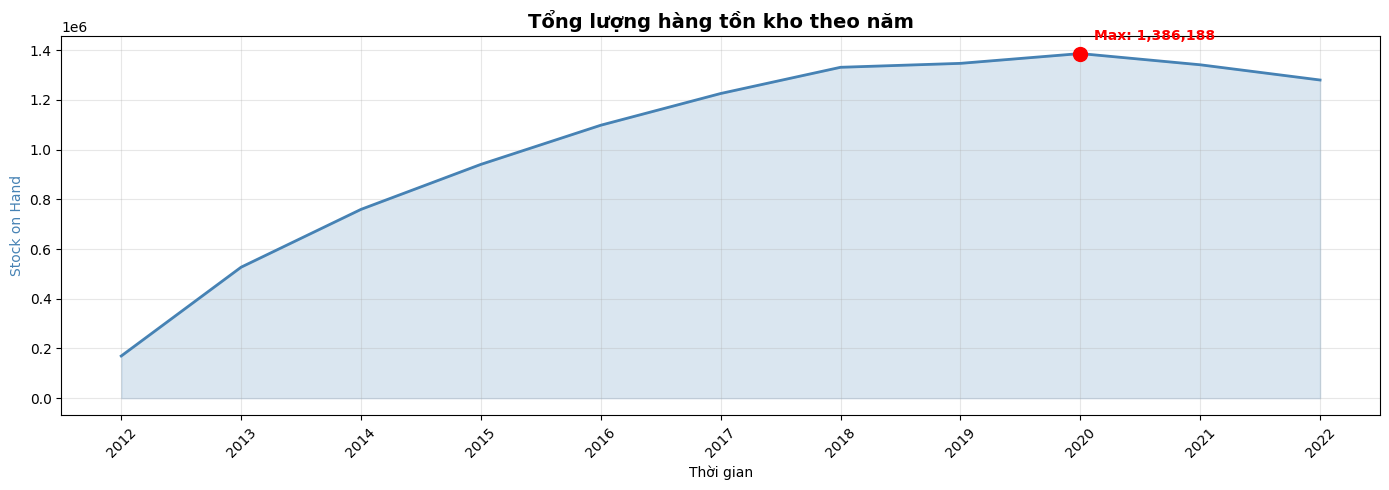

In [13]:
stock_by_date = df_inventory.groupby(['year']).agg(
    stock_on_hand=('stock_on_hand', 'sum')
).reset_index()

stock_by_date['period'] = stock_by_date['year'].astype(str)

max_idx = stock_by_date['stock_on_hand'].idxmax()
max_period = stock_by_date.loc[max_idx, 'period']
max_value = stock_by_date.loc[max_idx, 'stock_on_hand']

fig, ax1 = plt.subplots(figsize=(14, 5))

# Vẽ stock_on_hand
ax1.plot(
    stock_by_date['period'],
    stock_by_date['stock_on_hand'],
    color='steelblue',
    linewidth=2
)

ax1.fill_between(
    stock_by_date['period'],
    stock_by_date['stock_on_hand'],
    alpha=0.2,
    color='steelblue'
)

ax1.scatter(max_period, max_value, color='red', zorder=5, s=100)

ax1.annotate(
    f'Max: {max_value:,.0f}',
    xy=(max_period, max_value),
    xytext=(10, 10),
    textcoords='offset points',
    fontsize=10,
    color='red',
    fontweight='bold'
)

ax1.set_xlabel('Thời gian')
ax1.set_ylabel('Stock on Hand', color='steelblue')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

plt.title('Tổng lượng hàng tồn kho theo năm', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### **Sell-through rate giảm dần qua các năm**

In [14]:
# Tính trung bình sell-through rate qua từng năm
print(df_inventory.merge(df_inventory.groupby('year')['month'].max().reset_index(), on=['year','month']).groupby('year')['sell_through_rate'].mean().reset_index().to_string(index=False))
print(f"Trung bình sell-through rate: {df_inventory.merge(df_inventory.groupby('year')['month'].max().reset_index(), on=['year','month'])['sell_through_rate'].mean():.2%}")

 year  sell_through_rate
 2012           0.229099
 2013           0.180734
 2014           0.162554
 2015           0.147175
 2016           0.145724
 2017           0.130413
 2018           0.102114
 2019           0.103286
 2020           0.091846
 2021           0.136344
 2022           0.118345
Trung bình sell-through rate: 14.09%


- Tổng lượng hàng tồn kho tăng đều qua các năm, đạt đỉnh với số lượng hàng tồn là 1386188 vào năm 2020. 
- Tỷ lệ sell-through rate trung bình lao dốc từ nằm 2012 -> 2020. Ở các giai đoạn sau có tăng lên nhưng vẫn thấp hơn so với năm khởi điểm của dữ liệu, chỉ đạt ~11.8%.

## I.2. Các vấn đề của dữ liệu inventory

### **Sự bất đồng bộ giữa df_inventory và df_order_items**

In [15]:
df_order_with_dates = df_order_items.merge(df_orders, on='order_id', how='left')
df_order_items_final = df_order_with_dates.merge(df_shipments, on='order_id', how='left')
df_order_items_final['order_month'] = pd.to_datetime(df_order_items_final['order_date']).dt.to_period('M')
df_order_items_final['ship_month'] = pd.to_datetime(df_order_items_final['ship_date']).dt.to_period('M')
df_order_items_final['delivery_month'] = pd.to_datetime(df_order_items_final['delivery_date']).dt.to_period('M')

In [16]:
# 1. Tính delivered: group theo delivery_date
delivered = df_order_items_final[df_order_items_final['order_status'] == 'delivered'].copy()
delivered_grouped = delivered.groupby(['product_id', 'ship_month'])['quantity'].sum().reset_index(name='qty_delivered')

# 2. Tính shipped: group theo ship_date
shipped = df_order_items_final[df_order_items_final['order_status'] == 'shipped'].copy()
shipped_grouped = shipped.groupby(['product_id', 'ship_month'])['quantity'].sum().reset_index(name='qty_shipped')

# Ghép delivered với bảng df_inventory
df_inventory_final = df_inventory.copy()
df_inventory_final['year_month'] = pd.to_datetime(df_inventory_final['snapshot_date']).dt.to_period('M')
df_inventory_final = df_inventory_final.merge(delivered_grouped, left_on=['year_month', 'product_id'], right_on=['ship_month', 'product_id'], how='left')
# Ghép shipped với bảng df_inventory
df_inventory_final = df_inventory_final.merge(shipped_grouped, left_on=['year_month', 'product_id'], right_on=['ship_month', 'product_id'], how='left')
df_inventory_final['qty_delivered_shipped'] = df_inventory_final['qty_delivered'].fillna(0) + df_inventory_final['qty_shipped'].fillna(0)
df_inventory_final['qty_difference'] = df_inventory_final['qty_delivered_shipped'] - df_inventory_final['units_sold']
df_inventory_final = df_inventory_final.merge(df_products[['product_id', 'color', 'size', 'cogs']], on='product_id', how='left')

Tỷ lệ record mà units_sold = qty_delivered_shipped: 3.045794811359902%
Tỷ lệ record mà units_sold < qty_delivered_shipped: 83.78508473450961%
Tỷ lệ record mà units_sold > qty_delivered_shipped: 13.169120454130494%


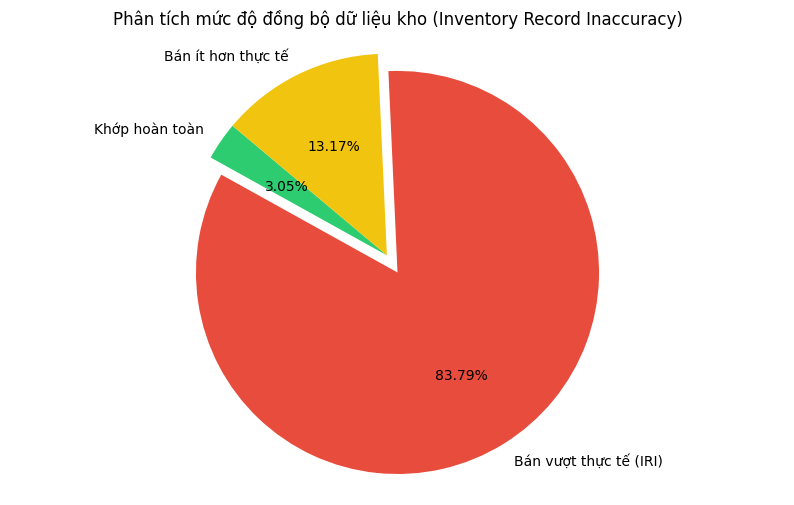

In [17]:
print(f"Tỷ lệ record mà units_sold = qty_delivered_shipped: {(len(df_inventory_final[df_inventory_final['qty_difference'] == 0])/len(df_inventory_final))*100}%")
print(f"Tỷ lệ record mà units_sold < qty_delivered_shipped: {(len(df_inventory_final[df_inventory_final['qty_difference'] > 0])/len(df_inventory_final))*100}%")
print(f"Tỷ lệ record mà units_sold > qty_delivered_shipped: {(len(df_inventory_final[df_inventory_final['qty_difference'] < 0])/len(df_inventory_final))*100}%")
# Chuẩn bị dữ liệu
labels = ['Khớp hoàn toàn', 'Bán vượt thực tế (IRI)', 'Bán ít hơn thực tế']
sizes = [
    len(df_inventory_final[df_inventory_final['qty_difference'] == 0]),
    len(df_inventory_final[df_inventory_final['qty_difference'] > 0]),
    len(df_inventory_final[df_inventory_final['qty_difference'] < 0])
]
colors = ['#2ecc71', '#e74c3c', '#f1c40f']

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.pie(sizes, labels=labels, autopct='%1.2f%%', startangle=140, colors=colors, explode=(0, 0.1, 0))
plt.title('Phân tích mức độ đồng bộ dữ liệu kho (Inventory Record Inaccuracy)')
plt.axis('equal') 
plt.show()

### **Lượng hàng tồn kho tăng tích lũy qua từng năm**

#### Giả thuyết số 1: Số lượng tồn kho có liên quan tới việc xử lý đơn hàng và thời gian vận chuyển không?

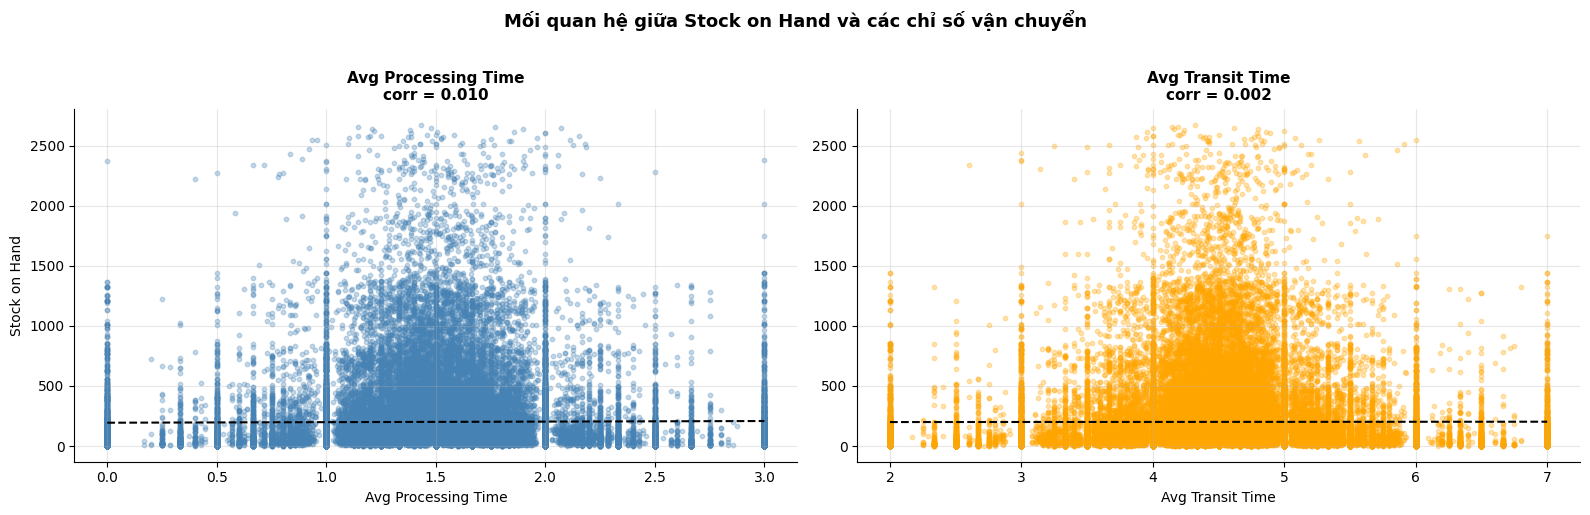

In [18]:
# Tính processing_time và transit_time
df_order_items_final['processing_time'] = (pd.to_datetime(df_order_items_final['ship_date']) - 
                                            pd.to_datetime(df_order_items_final['order_date'])).dt.days

df_order_items_final['transit_time'] = (pd.to_datetime(df_order_items_final['delivery_date']) - 
                                         pd.to_datetime(df_order_items_final['ship_date'])).dt.days

# Group theo product_id và month
df_order_items_final['ship_month'] = pd.to_datetime(df_order_items_final['ship_date']).dt.to_period('M')

shipping_monthly = df_order_items_final.groupby(['product_id', 'ship_month']).agg(
    avg_processing = ('processing_time', 'mean'),
    avg_transit    = ('transit_time', 'mean'),
).reset_index().rename(columns={'ship_month': 'year_month'})

# Merge với inventory
compare_shipping = pd.merge(
    df_inventory_final,
    shipping_monthly,
    on=['product_id', 'year_month'],
    how='inner'
)

corr_values = compare_shipping[['stock_on_hand', 'avg_processing', 'avg_transit']].corr()['stock_on_hand'].drop('stock_on_hand')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

scatter_pairs = [
    ('avg_processing', 'Avg Processing Time', 'steelblue'),
    ('avg_transit',    'Avg Transit Time',    'orange'),
]

for ax, (col, label, color) in zip(axes, scatter_pairs):
    ax.scatter(compare_shipping[col], compare_shipping['stock_on_hand'],
               alpha=0.3, s=10, color=color)
    
    # Trendline
    z = np.polyfit(compare_shipping[col].dropna(), 
                   compare_shipping.loc[compare_shipping[col].notna(), 'stock_on_hand'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(compare_shipping[col].min(), compare_shipping[col].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=1.5, linestyle='--')
    
    corr = compare_shipping[col].corr(compare_shipping['stock_on_hand'])
    ax.set_title(f'{label}\ncorr = {corr:.3f}', fontsize=11, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Stock on Hand' if col == 'avg_processing' else '')
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Mối quan hệ giữa Stock on Hand và các chỉ số vận chuyển', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Độ tương quan giữa số lượng hàng tồn cho mỗi sản phẩm và thời gian xử lý trung bình, thời gian vận chuyển trung bình rất thấp, cho thấy tình trạng tồn hàng không liên quan tới quá trình đơn hàng tới tay người người nhận.

#### Giả thuyết số 2: Liệu các stock on hand là những sản phẩm chết, được kho ghi nhận là không bao giờ được đem ra phục vụ nữa?

In [19]:
df_sorted = df_inventory_final.sort_values(by=['product_id', 'year', 'month'])
monotonic_check = df_sorted.groupby('product_id')['stock_on_hand'].is_monotonic_increasing

print("--- THỐNG KÊ XU HƯỚNG TỒN KHO CỦA CÁC SẢN PHẨM ---")
print(f"Tổng số sản phẩm (tính theo product_id) trong bảng df_inventory: {len(monotonic_check)}")
print(f"Số sản phẩm có tồn kho luôn tăng dần hoặc giữ nguyên theo thời gian: {monotonic_check.sum()}")
print(f"Tỷ lệ tồn kho tăng hoặc giữ nguyên theo thời gian: {(monotonic_check.sum() / len(monotonic_check)) * 100:.2f}%\n")

# Vẽ biểu đồ
# Tính độ chênh lệch tồn kho giữa tháng này và tháng trước của cùng 1 sản phẩm
df_sorted['stock_change'] = df_sorted.groupby('product_id')['stock_on_hand'].diff()

# Tìm những product_id đã từng có sự giảm tồn kho (stock_change < 0)
products_with_stock_drops = df_sorted[df_sorted['stock_change'] < 0]['product_id'].unique()
never_dropped_products = df_sorted[~df_sorted['product_id'].isin(products_with_stock_drops)]

# Gom nhóm để xem
zombie_growth = never_dropped_products.groupby(['product_id', 'product_name']).agg(
    months_alive=('month', 'count'),          # Sống được bao nhiêu tháng rồi?
    start_stock=('stock_on_hand', 'first'),   # Tồn kho tháng đầu tiên là bao nhiêu?
    end_stock=('stock_on_hand', 'last')       # Tồn kho tháng mới nhất là bao nhiêu?
).reset_index()

zombie_growth_1_year = zombie_growth[zombie_growth['months_alive'] >= 12]
zombie_growth_1_year = zombie_growth_1_year.sort_values(by='end_stock', ascending=False)

print("Top các sản phẩm tồn kho chỉ có tăng hoặc giữ nguyên trong hơn 1 năm")
display(zombie_growth_1_year.head(10))

--- THỐNG KÊ XU HƯỚNG TỒN KHO CỦA CÁC SẢN PHẨM ---
Tổng số sản phẩm (tính theo product_id) trong bảng df_inventory: 1624
Số sản phẩm có tồn kho luôn tăng dần hoặc giữ nguyên theo thời gian: 1624
Tỷ lệ tồn kho tăng hoặc giữ nguyên theo thời gian: 100.00%

Top các sản phẩm tồn kho chỉ có tăng hoặc giữ nguyên trong hơn 1 năm


,product_id,product_name,months_alive,start_stock,end_stock
550,791,HanoiStreet RP-79,111,45,2673
551,792,HanoiStreet RP-80,111,45,2617
418,604,SaigonFlex UC-69,126,380,2370
1403,2045,UrbanVN UE-05,125,175,2339
315,487,SaigonFlex UM-92,72,199,2014
574,826,HanoiStreet UM-10,126,406,1960
1570,2332,VietMotion UE-06,126,184,1939
805,1182,MekongFit UE-18,126,118,1913
610,927,HanoiStreet UE-36,117,236,1897
279,438,SaigonFlex UM-43,82,3,1744


**Nhận xét:** Công thức này cho thấy lượng hàng tồn đã bị lãng quên, khi các quản lý của kho hàng cứ nhập về theo số lượng bán ra mà không bao giờ kiểm tra kho hàng.

Sự chênh lệch giữa nhập và bán
count    60247.000000
mean         2.629044
std          5.927830
min          0.000000
50%          1.000000
75%          3.000000
90%          7.000000
95%         12.000000
max        161.000000
Name: units_difference, dtype: float64


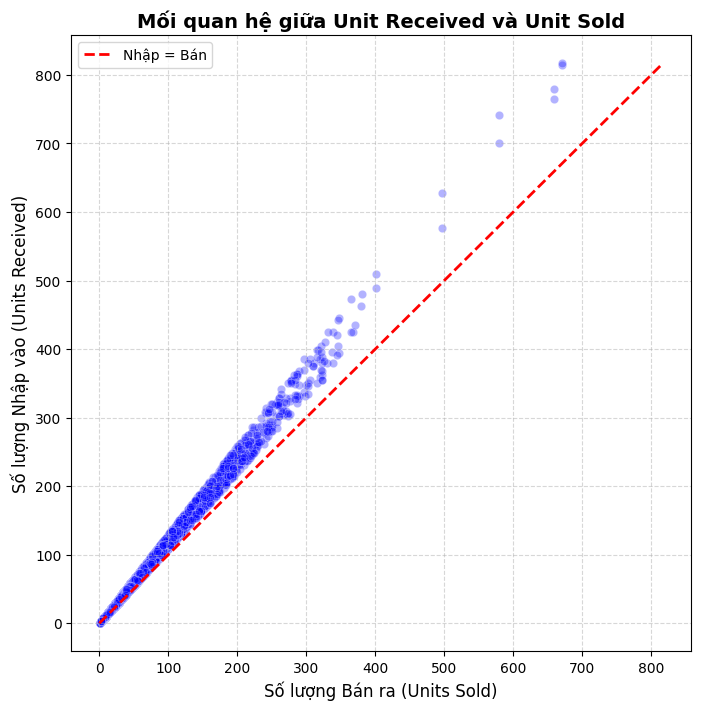

In [20]:
# Tính chênh lệch giữa nhập và bán
df_inventory_final['units_difference'] = df_inventory_final['units_received'] - df_inventory_final['units_sold']
print("Sự chênh lệch giữa nhập và bán")
# Dùng hàm describe() để in ra các mốc phần trăm (percentiles)
diff_stats = df_inventory_final['units_difference'].describe(percentiles=[0.5, 0.75, 0.9, 0.95])
print(diff_stats)

# Vẽ biểu đồ
plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_inventory_final, x='units_sold', y='units_received', alpha=0.3, color='blue')

max_val = max(df_inventory_final['units_sold'].max(), df_inventory_final['units_received'].max())
plt.plot([0, max_val], [0, max_val], color='red', linestyle='--', linewidth=2, label='Nhập = Bán')

plt.title('Mối quan hệ giữa Unit Received và Unit Sold', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng Bán ra (Units Sold)', fontsize=12)
plt.ylabel('Số lượng Nhập vào (Units Received)', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Độ tương quan giữa số lượng hàng tồn cho mỗi sản phẩm và thời gian xử lý trung bình, thời gian vận chuyển trung bình rất thấp, cho thấy tình trạng tồn hàng không liên quan tới quá trình đơn hàng tới tay người người nhận.

## I.3. Phân tích số liệu tồn kho

### **Trung bình days_of_supply theo category**

In [21]:
print("Trung bình days_of_supply theo category-segment:")
avg_days_of_supply_cat = df_inventory_final.groupby(['category', 'segment'])['days_of_supply'].mean().reset_index().sort_values(['category', 'days_of_supply'], ascending=False)
display(avg_days_of_supply_cat)


Trung bình days_of_supply theo category-segment:


,category,segment,days_of_supply
6,Streetwear,Everyday,1113.754685
5,Streetwear,Balanced,837.843114
7,Streetwear,Performance,745.608276
8,Streetwear,Standard,353.340134
3,Outdoor,Activewear,1112.712839
4,Outdoor,Premium,822.464802
2,GenZ,Trendy,718.812174
1,Casual,All-weather,494.709672
0,Casual,Activewear,199.386493


    Trong mặt hàng thời trang, theo nhóm research, vòng đời thời trang rất nhanh:
- Fast fashion: 30-45 ngày tồn kho
- Mid-market fashion: 60-90 ngày tồn kho
- Premium/luxury: 90-180 ngày tồn kho
- Basic/Essentials: 73-120 ngày tồn kho \
Tuy vậy, trung bình days_of_supply của từng category và segment lại trên 120 ngày. Ngay cả những phân khúc Trendy, thời trang hợp mốt là fast fashion cũng có thời gian có thể cung cấp hàng lên tới hơn 2 năm. 


### **Tổng lượng vốn chôn chia theo sell-through-rate**

In [22]:
df_inventory_final.groupby('overstock_flag')['sell_through_rate'].describe().round(3)

,count,mean,std,min,25%,50%,75%,max
overstock_flag,,,,,,,,
0,14305.0,0.356,0.113,0.25,0.250,0.327,0.415,0.853
1,45942.0,0.089,0.067,0.00,0.031,0.074,0.140,0.250


=> Định nghĩa:
- Dead Mover (STR < 25%): Hàng tồn đọng, khả năng thanh khoản cực thấp.
- Slow Mover (25% ≤ STR < 50%): Hàng luân chuyển chậm.
- Fast Mover (STR > 50%): Hàng lưu thông tốt, hiệu suất bán hàng cao.

Ước tính vốn bị chôn trung bình cuối mỗi năm (đơn vị: triệu)


sku_tier,Dead Movers (< 25%),Fast Movers (> 50%),Slow Movers (25-50%),Total Inventory Capital
year,,,,
2012,102.1,0.9,20.7,123.7
2013,179.7,2.1,15.4,197.2
2014,245.1,1.1,14.7,260.9
2015,303.1,0.6,12.4,316.1
2016,355.6,0.8,17.4,373.8
2017,385.8,0.8,7.2,393.8
2018,402.9,0.1,3.6,406.6
2019,434.0,0.0,4.1,438.2
2020,459.5,0.0,2.3,461.9


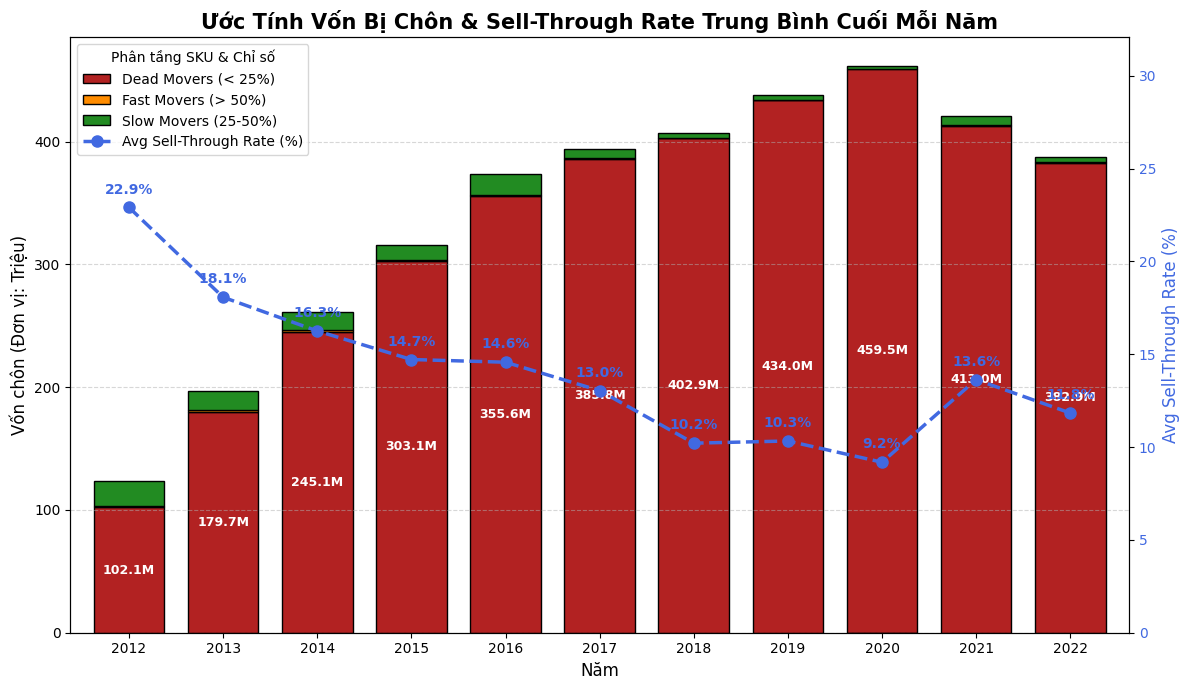

In [23]:
# Phân loại SKU Tiering
def tier_sku(str_rate):
    if str_rate < 0.25:
        return 'Dead Movers (< 25%)'
    elif 0.25 <= str_rate <= 0.50:
        return 'Slow Movers (25-50%)'
    else:
        return 'Fast Movers (> 50%)'

df_inventory_final['sku_tier'] = df_inventory_final['sell_through_rate'].apply(tier_sku)

# Tính vốn bị chôn
df_inventory_final['locked_capital'] = df_inventory_final['stock_on_hand'] * df_inventory_final['cogs']

# Lọc tháng chốt sổ cuối mỗi năm (Tháng 12)
end_of_year_months = df_inventory_final.groupby('year')['month'].max().reset_index()
df_eoy = pd.merge(df_inventory_final, end_of_year_months, on=['year', 'month'], how='inner')

# Tổng hợp vốn bị chôn theo năm và từng nhóm
yearly_tier_capital = df_eoy.groupby(['year', 'sku_tier'])['locked_capital'].sum().reset_index()
yearly_tier_capital['capital_in_millions'] = yearly_tier_capital['locked_capital'] / 1_000_000

pivot_table = yearly_tier_capital.pivot(
    index='year', columns='sku_tier', values='capital_in_millions'
).fillna(0)
pivot_table['Total Inventory Capital'] = pivot_table.sum(axis=1)

# Tính Sell-Through Rate TRUNG BÌNH của tháng cuối mỗi năm
avg_str_eoy = df_eoy.groupby('year')['sell_through_rate'].mean().reset_index()
avg_str_eoy.columns = ['year', 'avg_str']
avg_str_eoy = avg_str_eoy.set_index('year')

print("Ước tính vốn bị chôn trung bình cuối mỗi năm (đơn vị: triệu)")
display(pivot_table.round(1))

# Vẽ biểu đồ
plot_data = pivot_table.drop(columns=['Total Inventory Capital'])
colors = ['firebrick', 'darkorange', 'forestgreen']
dead_mover_col = 'Dead Movers (< 25%)'

fig, ax1 = plt.subplots(figsize=(12, 7))

# --- Stacked Bar (trục Y trái) ---
plot_data.plot(kind='bar', stacked=True, color=colors, ax=ax1, width=0.75, edgecolor='black')

ax1.set_title(
    'Ước Tính Vốn Bị Chôn & Sell-Through Rate Trung Bình Cuối Mỗi Năm',
    fontsize=15, fontweight='bold'
)
ax1.set_xlabel('Năm', fontsize=12)
ax1.set_ylabel('Vốn chôn (Đơn vị: Triệu)', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.tick_params(axis='x', rotation=0)

# Gắn label giá trị lên phần Dead Movers
if dead_mover_col in plot_data.columns:
    for i, (year, row) in enumerate(plot_data.iterrows()):
        dead_val = row[dead_mover_col]
        if dead_val > 0:
            # Dead Movers luôn là segment dưới cùng → y_center = dead_val / 2
            y_center = dead_val / 2
            ax1.text(
                i, y_center,
                f'{dead_val:.1f}M',
                ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white'
            )

# Đường Avg Sell-Through Rate
ax2 = ax1.twinx()

years = plot_data.index.tolist()
x_positions = range(len(years))
str_values = [avg_str_eoy.loc[y, 'avg_str'] * 100 for y in years]

ax2.plot(
    x_positions, str_values,
    color='royalblue', marker='o', linewidth=2.5,
    markersize=8, linestyle='--', label='Avg Sell-Through Rate (%)'
)

for x, val in zip(x_positions, str_values):
    ax2.annotate(
        f'{val:.1f}%',
        xy=(x, val),
        xytext=(0, 10), textcoords='offset points',
        ha='center', fontsize=10, color='royalblue', fontweight='bold'
    )

ax2.set_ylabel('Avg Sell-Through Rate (%)', fontsize=12, color='royalblue')
ax2.tick_params(axis='y', labelcolor='royalblue')
ax2.set_ylim(0, max(str_values) * 1.4)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2, labels1 + labels2,
    title='Phân tầng SKU & Chỉ số',
    fontsize=10, loc='upper left'
)

plt.tight_layout()
plt.show()

Nhóm Dead Movers chiếm tỷ trọng lớn nhất trong tổng lượng vốn bị chôn, đạt mức đỉnh vào năm 2020 với giá trị lên tới 459,5 triệu.

### **Biến động units_received, units_sold, stock_on_hand và số lượng SKU qua từng năm**

In [24]:
# Lọc lấy nhóm Dead Movers trong 3 năm quan trọng: 2020, 2021, 2022
df_investigate = df_inventory_final[
                           (df_inventory_final['sku_tier'] == 'Dead Movers (< 25%)')]

# Gom nhóm theo năm để tính tổng các chỉ số "sinh tồn"
investigation_report = df_investigate.groupby('year').agg(
    total_dead_skus=('product_id', 'nunique'),          
    total_units_received=('units_received', 'sum'),    
    total_units_sold=('units_sold', 'sum'),             
    total_stock_on_hand=('stock_on_hand', 'sum')        
).reset_index()

# Tính toán tỷ lệ thay đổi (YoY Growth) để thấy rõ sự biến động
# Lấy độ lệch của năm sau trừ năm trước
for col in ['total_dead_skus', 'total_units_received', 'total_units_sold', 'total_stock_on_hand']:
    investigation_report[f'{col}_YoY'] = investigation_report[col].diff()

print("Hồ sơ điều tra nhóm Dead Movers:")
display(investigation_report)

Hồ sơ điều tra nhóm Dead Movers:


,year,total_dead_skus,total_units_received,total_units_sold,total_stock_on_hand,total_dead_skus_YoY,total_units_received_YoY,total_units_sold_YoY,total_stock_on_hand_YoY
0,2012,392,28653,24321,126588,NaN,NaN,NaN,NaN
1,2013,517,81879,69713,444217,125.0,53226.0,45392.0,317629.0
2,2014,577,87955,74964,683763,60.0,6076.0,5251.0,239546.0
3,2015,611,108531,92251,891451,34.0,20576.0,17287.0,207688.0
4,2016,639,105289,89448,1047090,28.0,-3242.0,-2803.0,155639.0
5,2017,652,100275,85262,1183385,13.0,-5014.0,-4186.0,136295.0
6,2018,684,93088,79404,1297961,32.0,-7187.0,-5858.0,114576.0
7,2019,666,59766,51446,1334414,-18.0,-33322.0,-27958.0,36453.0
8,2020,688,48735,42241,1374394,22.0,-11031.0,-9205.0,39980.0
9,2021,664,43730,37935,1323394,-24.0,-5005.0,-4306.0,-51000.0


### **Trung bình vốn chôn theo mùa**

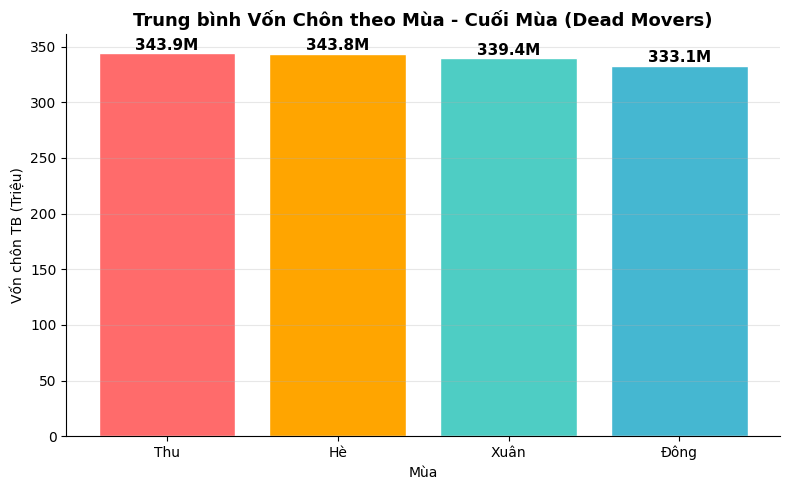

In [25]:
# Lấy tháng cuối của mỗi mùa: tháng 3, 6, 9, 12
end_of_season_months = [3, 6, 9, 12]

df_inventory_final['season'] = df_inventory_final['month'].map({
    1: 'Xuân', 2: 'Xuân', 3: 'Xuân',
    4: 'Hè',   5: 'Hè',   6: 'Hè',
    7: 'Thu',  8: 'Thu',  9: 'Thu',
    10: 'Đông', 11: 'Đông', 12: 'Đông'
})

seasonal_capital = df_inventory_final[
    (df_inventory_final['sku_tier'] == 'Dead Movers (< 25%)') &
    (df_inventory_final['month'].isin(end_of_season_months))  # Chỉ lấy tháng cuối mùa
]\
    .groupby(['year', 'season'])['locked_capital'].sum().reset_index()\
    .groupby('season')['locked_capital'].mean()\
    .reset_index(name='avg_locked_capital')\
    .assign(capital_in_millions=lambda x: x['avg_locked_capital'] / 1_000_000)\
    .sort_values('capital_in_millions', ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(seasonal_capital['season'], seasonal_capital['capital_in_millions'],
              color=['#FF6B6B', '#FFA500', '#4ECDC4', '#45B7D1'], edgecolor='white')

for bar, val in zip(bars, seasonal_capital['capital_in_millions']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:,.1f}M', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Trung bình Vốn Chôn theo Mùa - Cuối Mùa (Dead Movers)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mùa')
ax.set_ylabel('Vốn chôn TB (Triệu)')
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Nhận xét:** Trung bình vốn chôn theo mùa không liên quan tới việc khối hàng đang phình to, khi các mùa đều có tổng vốn chôn cho nhóm Dead Movers gần xấp xỉ nhau.

### **Top 3 Category x Segment có vốn chôn nhiều nhất qua từng năm**

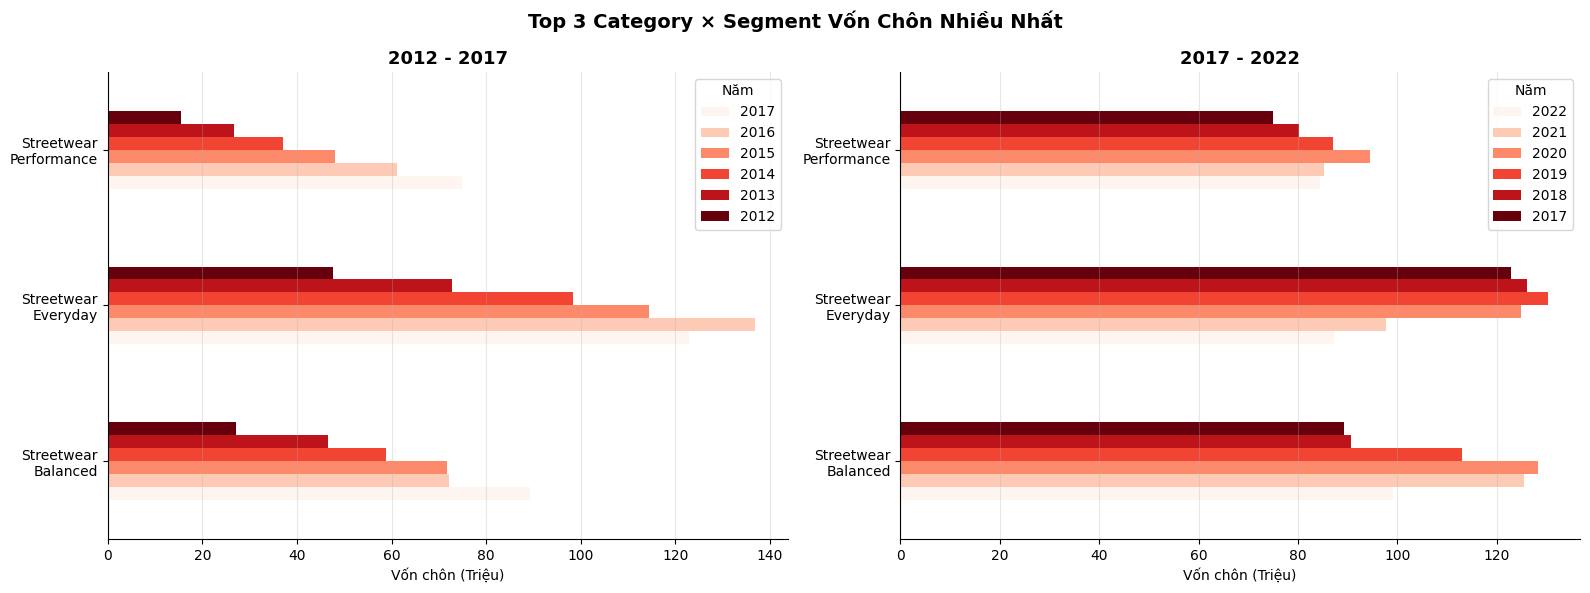

In [26]:
dead_movers_eoy = df_eoy[df_eoy['sku_tier'] == 'Dead Movers (< 25%)']

top_segments = dead_movers_eoy.groupby(['year', 'category', 'segment']).agg(
    total_locked_capital=('locked_capital', 'sum')
).reset_index()\
.assign(
    capital_in_millions=lambda x: x['total_locked_capital'] / 1_000_000,
    combo=lambda x: x['category'] + '\n' + x['segment']
)\
.sort_values(['year', 'total_locked_capital'], ascending=[True, False])\
.groupby('year').head(3)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (start, end) in zip(axes, [(2012, 2017), (2017, 2022)]):
    data = top_segments[(top_segments['year'] >= start) & (top_segments['year'] <= end)]
    
    pivot = data.pivot_table(index='combo', columns='year', values='capital_in_millions', aggfunc='sum').fillna(0)
    pivot = pivot[sorted(pivot.columns, reverse=True)]  
    pivot.plot(kind='barh', ax=ax, colormap='Reds')
    
    ax.set_title(f'{start} - {end}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Vốn chôn (Triệu)')
    ax.set_ylabel('')
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(title='Năm', bbox_to_anchor=(1, 1))

fig.suptitle('Top 3 Category × Segment Vốn Chôn Nhiều Nhất', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
plt.show()

### **Top 10 sản phẩm:**

- **Tồn kho cao nhưng units_sold vẫn nhiều**

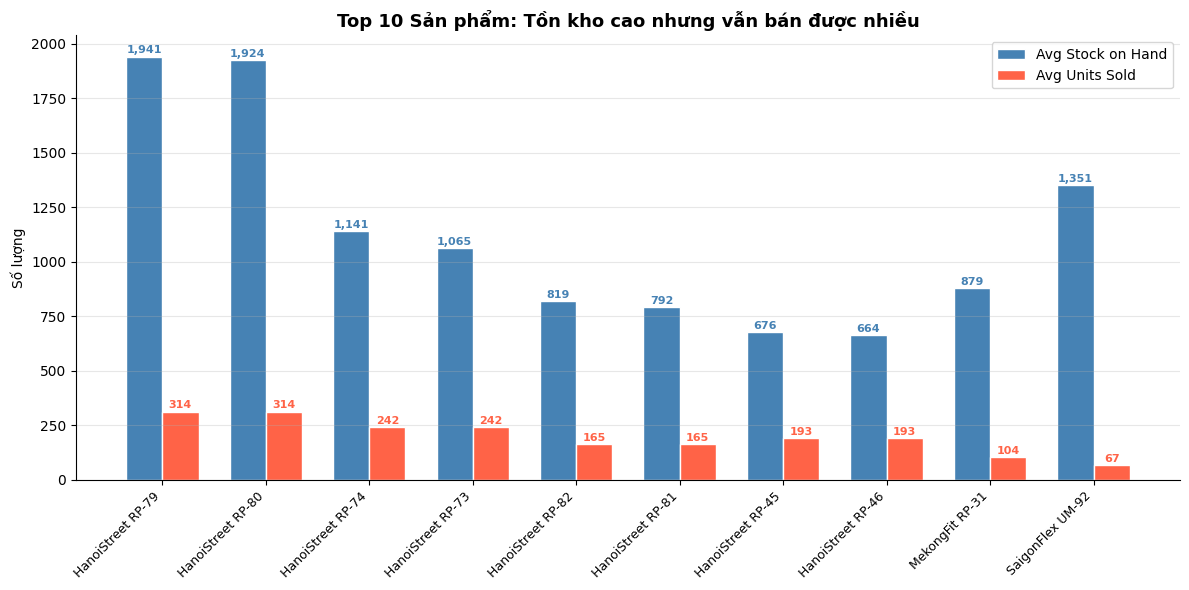

In [27]:
top10 = df_inventory_final[df_inventory_final['month'] == 12]\
    .groupby(['product_id', 'product_name']).agg(
        avg_eoy_stock = ('stock_on_hand', 'mean'),
        avg_eoy_sold  = ('units_sold', 'mean')
    ).reset_index()\
    .assign(combined_score = lambda x: x['avg_eoy_stock'] * x['avg_eoy_sold'])\
    .sort_values('combined_score', ascending=False)\
    .head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(top10))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top10['avg_eoy_stock'], width, 
               label='Avg Stock on Hand', color='steelblue', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], top10['avg_eoy_sold'], width, 
               label='Avg Units Sold', color='tomato', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='steelblue', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='tomato', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(top10['product_name'], rotation=45, ha='right', fontsize=9)
ax.set_title('Top 10 Sản phẩm: Tồn kho cao nhưng vẫn bán được nhiều', fontsize=13, fontweight='bold')
ax.set_ylabel('Số lượng')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
plt.show()

- **Units_sold cao và tồn kho thấp**

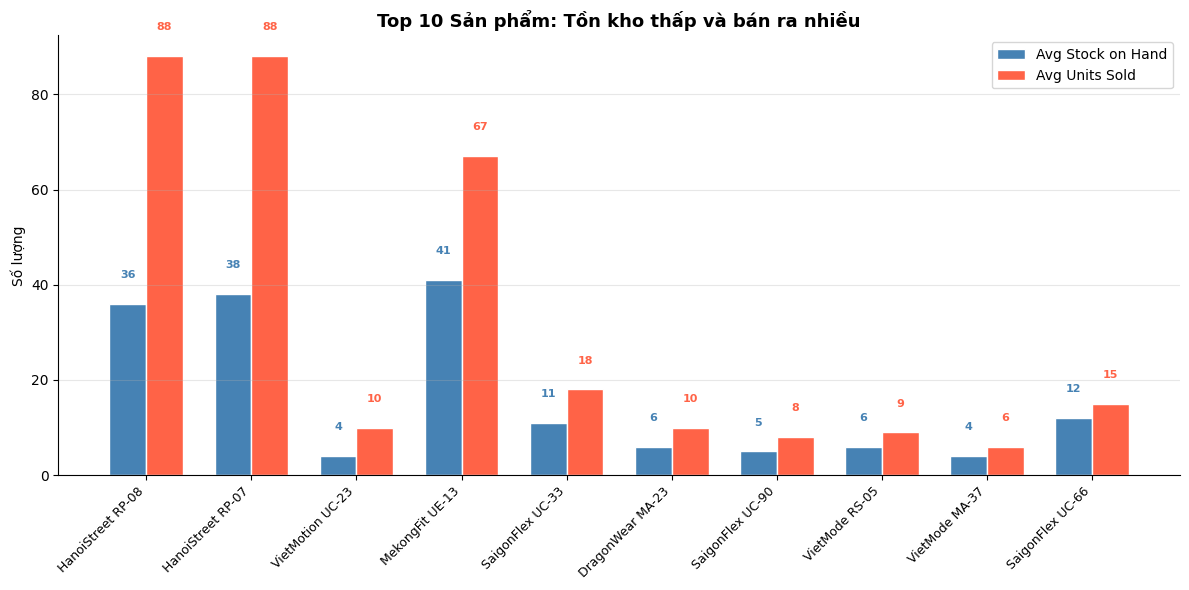

In [28]:
top10_fast = df_inventory_final[df_inventory_final['month'] == 12]\
    .groupby(['product_id', 'product_name']).agg(
        avg_eoy_stock = ('stock_on_hand', 'mean'),
        avg_eoy_sold  = ('units_sold', 'mean')
    ).reset_index()\
    .assign(combined_score = lambda x: x['avg_eoy_sold'] / (x['avg_eoy_stock'] + 1))\
    .sort_values('combined_score', ascending=False)\
    .head(10)

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(top10_fast))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], top10_fast['avg_eoy_stock'], width, 
               label='Avg Stock on Hand', color='steelblue', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], top10_fast['avg_eoy_sold'], width, 
               label='Avg Units Sold', color='tomato', edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='steelblue', fontweight='bold')

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=8, color='tomato', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(top10_fast['product_name'], rotation=45, ha='right', fontsize=9)
ax.set_title('Top 10 Sản phẩm: Tồn kho thấp và bán ra nhiều', fontsize=13, fontweight='bold')
ax.set_ylabel('Số lượng')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()
plt.show()

**Nhận xét**: Số lượng hàng bán ra cho thấy mối tương quan thuận với lượng hàng tồn kho: những sản phẩm có doanh số cao thường đi kèm với mức tồn kho lớn, trong nhiều trường hợp cao gấp 5–6 lần số lượng bán ra.

# II. Promotions

> Tính toán cho mục đích phân tích doanh thu

In [29]:
items = (
    df_order_items
    .merge(df_products[['product_id','category','segment','cogs','price']], on='product_id', how='left')
    .merge(df_orders[['order_id','order_date','customer_id','order_status']], on='order_id', how='left')
)

# Adds cost metric
items['gross_demand']   = items['unit_price']  * items['quantity']          # Qty × UnitPrice
items['net_revenue']    = items['gross_demand'] - items['discount_amount']  # sau giảm giá
items['total_cogs']     = items['cogs']         * items['quantity']          # Qty × COGS
items['gross_profit']   = items['net_revenue']  - items['total_cogs']        # lãi/lỗ thực
items['margin_pct']     = items['gross_profit'] / items['net_revenue']       # biên lợi nhuận
items['discount_rate']  = items['discount_amount'] / items['gross_demand']   # % giảm giá thực

# promo_flag: đơn có ít nhất 1 mã KM
items['promo_flag'] = (items['promo_id'].notna() | items['promo_id_2'].notna()).astype(int)

print(f'Tổng số items: {len(items):,}')
print(f'Số lượng items có áp dụng khuyến mãi: {items["promo_flag"].sum():,} ({items["promo_flag"].mean()*100:.1f}%)')
items.head(3)

Tổng số items: 714,669
Số lượng items có áp dụng khuyến mãi: 276,316 (38.7%)


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,category,segment,cogs,...,order_date,customer_id,order_status,gross_demand,net_revenue,total_cogs,gross_profit,margin_pct,discount_rate,promo_flag
0,1,2400,7,1138.22,0.0,NaN,NaN,GenZ,Trendy,1053.798008,...,2012-07-04,58578,delivered,7967.54,7967.54,7376.586059,590.953941,0.074170,0.0,0
1,2,609,7,10166.25,0.0,NaN,NaN,Streetwear,Everyday,8987.704231,...,2012-07-04,58621,returned,71163.75,71163.75,62913.929616,8249.820384,0.115927,0.0,0
2,3,396,3,11220.33,0.0,NaN,NaN,Streetwear,Balanced,10091.012256,...,2012-07-04,58811,delivered,33660.99,33660.99,30273.036767,3387.953233,0.100649,0.0,0


In [30]:
items.columns

Index(['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount',
       'promo_id', 'promo_id_2', 'category', 'segment', 'cogs', 'price',
       'order_date', 'customer_id', 'order_status', 'gross_demand',
       'net_revenue', 'total_cogs', 'gross_profit', 'margin_pct',
       'discount_rate', 'promo_flag'],
      dtype='object')

## II.1 Xác định các vấn đề của khuyến mãi

> ### II.1.1 Overall

In [31]:
overall = {
    'gross_demand':  items['gross_demand'].sum(),
    'net_revenue':   items['net_revenue'].sum(),
    'total_cogs':    items['total_cogs'].sum(),
    'discount_amt':  items['discount_amount'].sum(),
    'gross_profit':  items['gross_profit'].sum(),
}
overall['margin_pct'] = overall['gross_profit'] / overall['net_revenue']

pd.DataFrame([overall]).style.format({
    'gross_demand': '{:,.0f}', 'net_revenue': '{:,.0f}',
    'total_cogs':   '{:,.0f}', 'discount_amt':'{:,.0f}',
    'gross_profit': '{:,.0f}', 'margin_pct':  '{:.2%}'
})


,gross_demand,net_revenue,total_cogs,discount_amt,gross_profit,margin_pct
0,"16,430,476,586","15,680,869,265","14,163,450,519","749,607,320","1,517,418,746",9.68%


In [32]:
items['year'] = items['order_date'].dt.year
yearly_revenue = items.groupby('year').agg(
num_items     = ('order_id',       'size'),
gross_demand  = ('gross_demand',   'sum'),
discount_amt  = ('discount_amount','sum'),
net_revenue   = ('net_revenue',    'sum'),
total_cogs    = ('total_cogs',     'sum'),
gross_profit  = ('gross_profit',   'sum'),
).reset_index()
yearly_revenue

,year,num_items,gross_demand,discount_amt,net_revenue,total_cogs,gross_profit
0,2012,37007,7.414977e+08,0.00,7.414977e+08,5.874619e+08,1.540358e+08
1,2013,87341,1.657169e+09,87004248.57,1.570165e+09,1.465980e+09,1.041851e+08
2,2014,91086,1.871846e+09,86503167.66,1.785343e+09,1.574607e+09,2.107353e+08
3,2015,92537,1.889934e+09,97923860.36,1.792010e+09,1.665442e+09,1.265681e+08
4,2016,90895,2.104641e+09,92276211.92,2.012364e+09,1.780559e+09,2.318051e+08
5,2017,83691,1.911164e+09,95617691.30,1.815547e+09,1.694386e+09,1.211608e+08
6,2018,75132,1.850122e+09,80399276.46,1.769723e+09,1.542176e+09,2.275474e+08
7,2019,44925,1.136801e+09,55211860.32,1.081590e+09,1.005203e+09,7.638670e+07
8,2020,37238,1.054512e+09,48403622.41,1.006109e+09,8.860851e+08,1.200234e+08
9,2021,36749,1.043040e+09,51825645.91,9.912142e+08,9.411301e+08,5.008405e+07


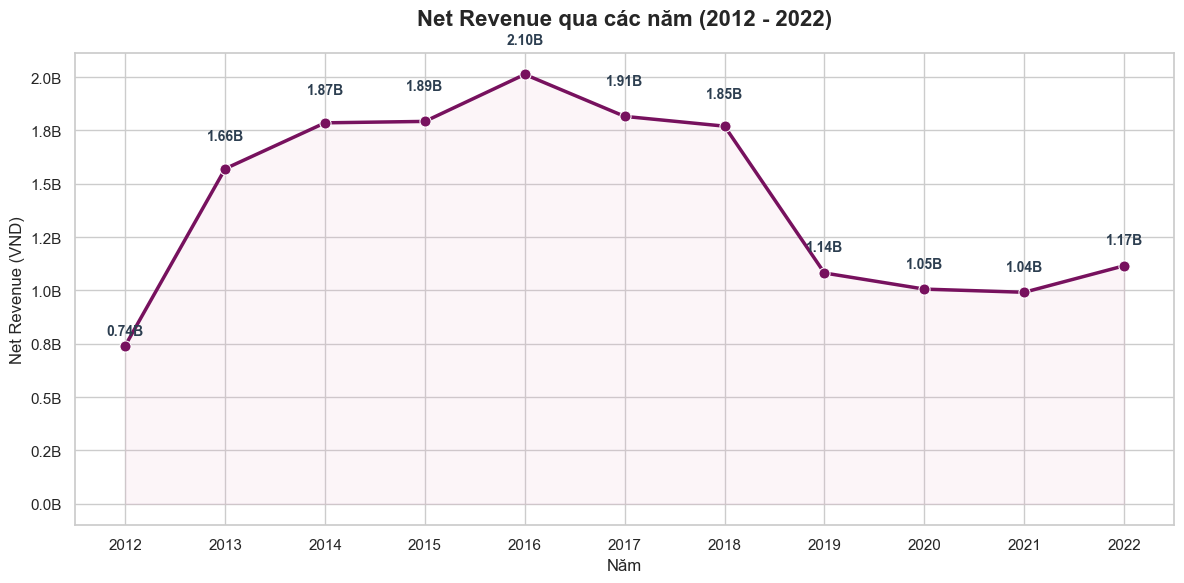

In [33]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
line_plot = sns.lineplot(
    data=yearly_revenue, x='year', y='net_revenue', 
    marker='o', markersize=8, linewidth=2.5, color="#77115e"
)

plt.fill_between(yearly_revenue['year'], yearly_revenue['net_revenue'], color="#eba2c4", alpha=0.1)

# 5. Định dạng tiêu đề và nhãn
plt.title('Net Revenue qua các năm (2012 - 2022)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Net Revenue (VND)', fontsize=12)

def format_billions(x, pos):
    return f'{x/1e9:.1f}B'
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_billions))

for i in range(yearly_revenue.shape[0]):
    plt.text(
        yearly_revenue.year[i], yearly_revenue.gross_demand[i] + 5e7, 
        f'{yearly_revenue.gross_demand[i]/1e9:.2f}B', 
        ha='center', fontsize=10, fontweight='bold', color='#2c3e50'
    )

plt.xticks(yearly_revenue['year']) 
plt.tight_layout()
plt.show()

Tỷ suất lợi nhuận rất mỏng so với 1 doanh nghiệp bán hàng thời trang. Chưa kể đến các chi phí vận hành, logistic, marketing thì có thể nói doanh nghiệp này đang bán để hòa vốn hoặc thậm chí lỗ

> ### II.1.2. Promotion vs. No-Promotion

In [34]:
t2 = items.groupby('promo_flag').agg(
    num_items     = ('order_id',       'size'),
    gross_demand  = ('gross_demand',   'sum'),
    discount_amt  = ('discount_amount','sum'),
    net_revenue   = ('net_revenue',    'sum'),
    total_cogs    = ('total_cogs',     'sum'),
    gross_profit  = ('gross_profit',   'sum'),
).assign(
    margin_pct = lambda d: d['gross_profit'] / d['net_revenue'],
    avg_discount_rate = lambda d: d['discount_amt'] / d['gross_demand']
)
t2.index = ['No Promo', 'Promo']
print('=== PROMO vs NON-PROMO ===')
t2.style.format({
    'num_items':'{:,.0f}', 'gross_demand':'{:,.0f}', 'discount_amt':'{:,.0f}',
    'net_revenue':'{:,.0f}','total_cogs':'{:,.0f}',  'gross_profit':'{:,.0f}',
    'margin_pct':'{:.2%}', 'avg_discount_rate':'{:.2%}'
}).applymap(lambda x: 'color: #ff4d6d' if isinstance(x,float) and x < 0 else '',
            subset=['gross_profit','margin_pct'])

=== PROMO vs NON-PROMO ===


,num_items,gross_demand,discount_amt,net_revenue,total_cogs,gross_profit,margin_pct,avg_discount_rate
No Promo,"438,353","10,995,039,053",0,"10,995,039,053","8,800,023,667","2,195,015,386",19.96%,0.00%
Promo,"276,316","5,435,437,533","749,607,320","4,685,830,213","5,363,426,852","-677,596,639",-14.46%,13.79%


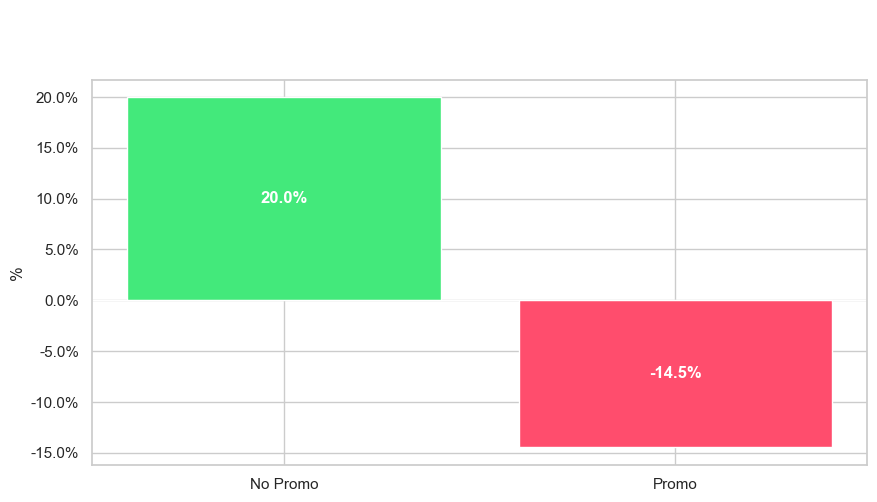

In [35]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Promo vs Non-Promo: Doanh thu & Lợi nhuận', fontsize=14, color='white', y=1.02)

groups   = ['No Promo', 'Promo']
colors_p = [OK, ACCENT]

# Left: Margin %
bars = ax.bar(groups, t2['margin_pct']*100,
              color=[OK if v > 0 else ACCENT for v in t2['margin_pct']])
ax.axhline(0, color='white', lw=0.8)
ax.set_title('Profit Margin %', color='white')
ax.set_ylabel('%')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f%%'))
for bar, val in zip(bars, t2['margin_pct']):
    y_pos = bar.get_height() / 2 
    ax.text(bar.get_x() + bar.get_width()/2, y_pos,
            f'{val*100:.1f}%', ha='center', va='center', color='white', fontweight='bold', fontsize=12)


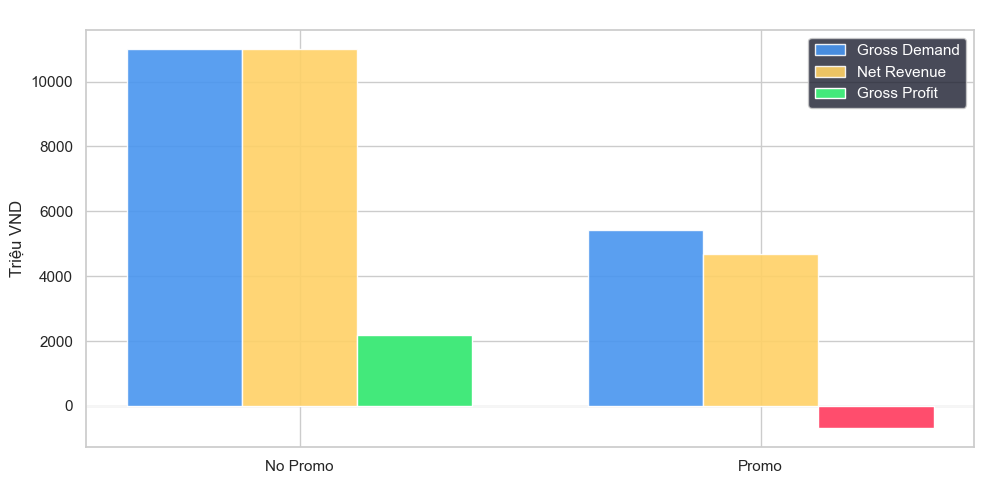

In [36]:
fig, ax= plt.subplots(figsize=(10,5))
x  = np.arange(2)
w  = 0.25
ax.bar(x - w, t2['gross_demand']/1e6,  width=w, label='Gross Demand', color=BLUE,   alpha=0.9)
ax.bar(x,     t2['net_revenue']/1e6,   width=w, label='Net Revenue',  color=YELLOW, alpha=0.9)
ax.bar(x + w, t2['gross_profit']/1e6,  width=w, label='Gross Profit', 
        color=[OK if v>0 else ACCENT for v in t2['gross_profit']])
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_title('Revenue Breakdown (triệu VND)', color='white')
ax.set_ylabel('Triệu VND')
ax.legend(facecolor='#1a1d2e', labelcolor='white')
ax.axhline(0, color='white', lw=0.6)

plt.tight_layout()
plt.savefig('t2_promo_vs_nonpromo.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

Có thể thấy việc áp dụng mã giảm giá làm cho doang nghiệp đang lỗ nặng, dẫn đến lãi suất âm.

## II.2 Đi sâu vào categories

### **All items**

In [37]:
cate_df = items[['order_id','category','net_revenue', 'gross_profit']].copy()
summary_display = cate_df.groupby('category').agg({
    'order_id': 'size',
    'net_revenue': 'sum',
    'gross_profit': 'sum',
})
summary_display['margin_profit'] = (summary_display['gross_profit'] / summary_display['net_revenue'])
summary_display = summary_display.rename(columns={'order_id': 'num_of_items'})
formatted_summary = summary_display.style.format({
    'num_of_items': '{:,.0f}',
    'net_revenue': '{:,.0f}',
    'gross_profit': '{:,.0f}',
    'margin_profit': '{:.2%}',
}).applymap(lambda x: 'color: red' if x < 0 else '', subset=['gross_profit'])

formatted_summary


,num_of_items,net_revenue,gross_profit,margin_profit
category,,,,
Casual,"23,991","440,285,194","33,740,765",7.66%
GenZ,"37,159","328,710,176","50,836,377",15.47%
Outdoor,"259,986","2,353,396,797","267,034,092",11.35%
Streetwear,"393,533","12,558,477,099","1,165,807,512",9.28%


### **Promotion only**

In [38]:
promo_cate_df = items[items['promo_flag']==1][['order_id','category','net_revenue','gross_profit']]
summary_display = promo_cate_df.groupby('category').agg({
    'order_id':    'size',
    'net_revenue': 'sum',
    'gross_profit':'sum',
})
summary_display['margin_profit'] = summary_display['gross_profit'] / summary_display['net_revenue']
summary_display = summary_display.rename(columns={'order_id':'num_of_items'})

summary_display.style.format({
    'num_of_items': '{:,.0f}',
    'net_revenue':  '{:,.0f}',
    'gross_profit': '{:,.0f}',
    'margin_profit':'{:.2%}',      
}).map(lambda x: 'color: red'   if isinstance(x, float) and x < 0 else
                 'color: green' if isinstance(x, float) and x > 0 else '',
       subset=['gross_profit','margin_profit'])

,num_of_items,net_revenue,gross_profit,margin_profit
category,,,,
Casual,"8,075","118,328,330","-18,354,209",-15.51%
GenZ,"12,232","85,899,805","-4,937,656",-5.75%
Outdoor,"108,341","764,184,900","-75,649,349",-9.90%
Streetwear,"147,668","3,717,417,177","-578,655,426",-15.57%


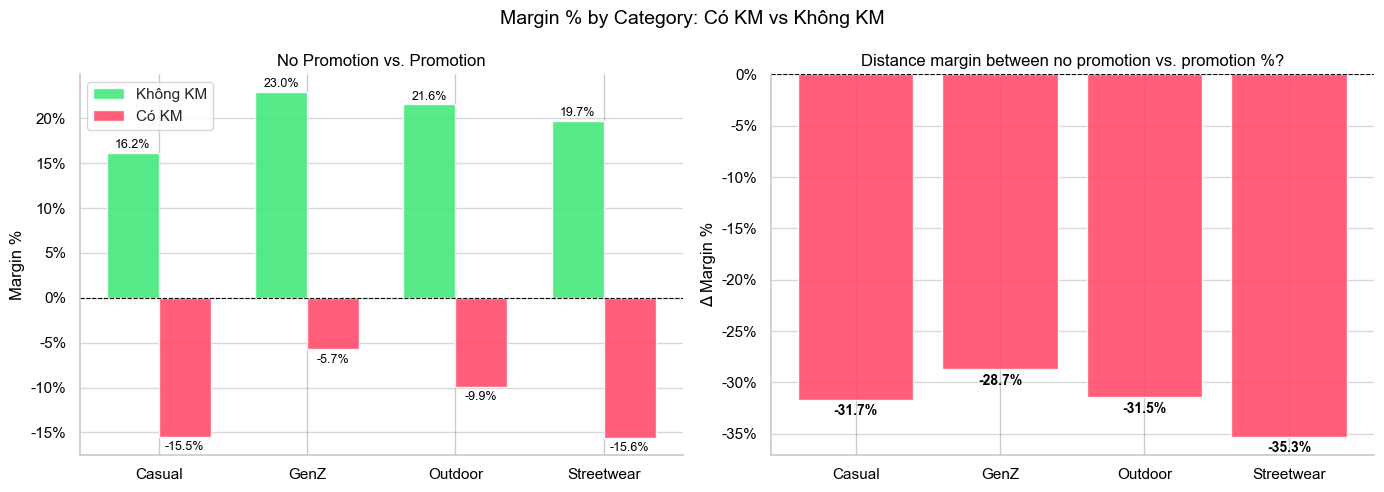

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('white')
fig.suptitle('Margin % by Category: Có KM vs Không KM', fontsize=14, color='black')

# Data không KM
no_promo = items[items['promo_flag']==0].groupby('category').agg(
    net_revenue  = ('net_revenue',  'sum'),
    gross_profit = ('gross_profit', 'sum'),
).assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])

# Data có KM
with_promo = items[items['promo_flag']==1].groupby('category').agg(
    net_revenue  = ('net_revenue',  'sum'),
    gross_profit = ('gross_profit', 'sum'),
).assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])

categories = no_promo.index.tolist()
x = np.arange(len(categories))
w = 0.35

for ax in axes:
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.tick_params(colors='black')


ax = axes[0]
ax.bar(x - w/2, no_promo['margin_pct']*100,  width=w, color=OK,    label='Không KM', alpha=0.9)
ax.bar(x + w/2, with_promo['margin_pct']*100, width=w, color=ACCENT, label='Có KM',    alpha=0.9)
ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(categories, color='black')
ax.set_ylabel('Margin %', color='black')
ax.set_title('No Promotion vs. Promotion', color='black')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend()
ax.grid(axis='y', alpha=0.3, color='gray')

# Annotate
for i, (nv, wv) in enumerate(zip(no_promo['margin_pct'], with_promo['margin_pct'])):
    ax.text(i - w/2, nv*100 + 0.5, f'{nv*100:.1f}%', ha='center', fontsize=9, color='black')
    ax.text(i + w/2, wv*100 - 1.5 if wv < 0 else wv*100 + 0.5,
            f'{wv*100:.1f}%', ha='center', fontsize=9, color='black')


ax2 = axes[1]
delta = (with_promo['margin_pct'] - no_promo['margin_pct']) * 100
bar_c = [ACCENT if v < 0 else OK for v in delta]
bars = ax2.bar(categories, delta, color=bar_c, alpha=0.9)
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.set_title('Distance margin between no promotion vs. promotion %?', color='black')
ax2.set_ylabel('Δ Margin %', color='black')
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax2.grid(axis='y', alpha=0.3, color='gray')
ax2.tick_params(colors='black')

for bar, val in zip(bars, delta):
    y_pos = val - 1.5 if val < 0 else val + 0.3
    ax2.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:+.1f}%', ha='center', fontsize=10,
             color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('category_margin_compare.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

* Khuyến mãi đang biến lợi nhuận âm thành âm trong tất cả các categories -> khuyến mãi chính là nguyên nhân làm doanh nghiệp thua lỗ

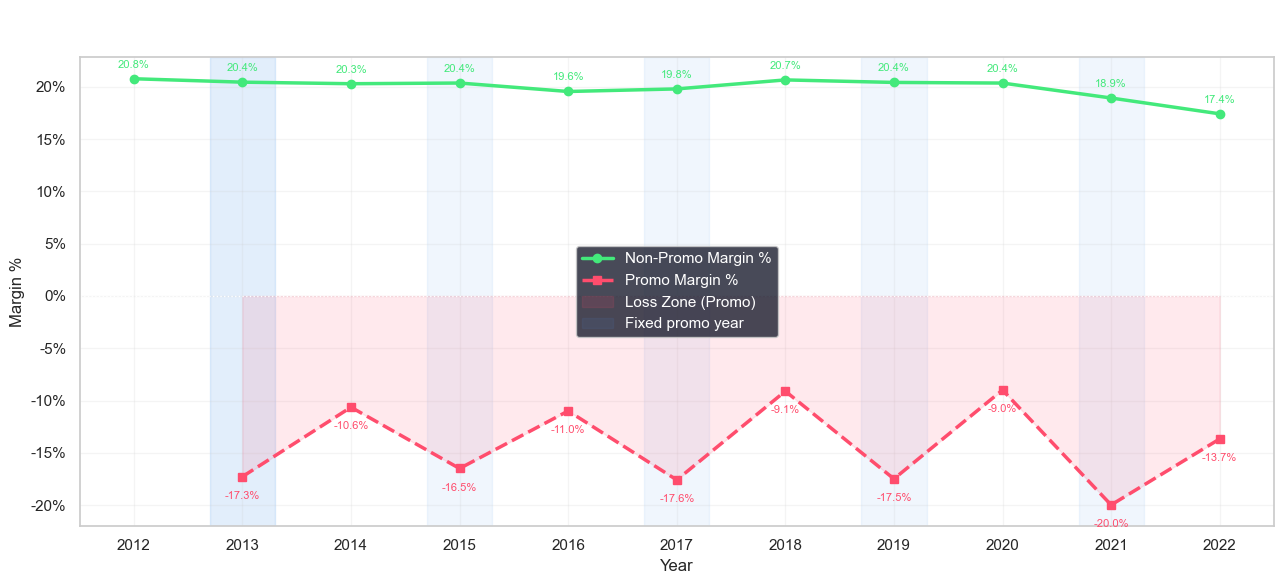

In [40]:
t3 = items.groupby(['year','promo_flag']).agg(
    net_revenue  = ('net_revenue',   'sum'),
    gross_profit = ('gross_profit',  'sum'),
).assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])

df_compare = t3['margin_pct'].unstack('promo_flag')
df_compare.columns = ['Non-Promo', 'Promo']
df_compare = df_compare.sort_index()

fixed_years = [yr for yr in df_compare.index 
               if yr in df_promotions[df_promotions['promo_type']=='fixed']['start_date'].dt.year.values]

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(df_compare.index, df_compare['Non-Promo'] * 100,
        marker='o', color=OK,    label='Non-Promo Margin %', lw=2.5)
ax.plot(df_compare.index, df_compare['Promo'] * 100,
        marker='s', color=ACCENT, label='Promo Margin %',    lw=2.5, linestyle='--')

ax.fill_between(df_compare.index, df_compare['Promo'] * 100, 0,
                where=(df_compare['Promo'] < 0),
                color=ACCENT, alpha=0.12, label='Loss Zone (Promo)')

for yr in fixed_years:
    ax.axvspan(yr - 0.3, yr + 0.3, alpha=0.08, color=BLUE, zorder=0)
if fixed_years:
    ax.axvspan(fixed_years[0] - 0.3, fixed_years[0] + 0.3,
               alpha=0.08, color=BLUE, zorder=0, label='Fixed promo year')

for yr, val in df_compare['Promo'].items():
    ax.annotate(f'{val*100:.1f}%',
                xy=(yr, val*100),
                xytext=(0, -16), textcoords='offset points',
                ha='center', fontsize=8, color=ACCENT)

for yr, val in df_compare['Non-Promo'].items():
    ax.annotate(f'{val*100:.1f}%',
                xy=(yr, val*100),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8, color=OK)

ax.axhline(0, color='white', lw=1, linestyle=':')
ax.set_title('Tầng 3 — Margin % theo năm: Promo vs Non-Promo\n'
             '(vùng xanh = năm có fixed promo, vùng đỏ = loss zone)',
             color='white', fontsize=13)
ax.set_ylabel('Margin %')
ax.set_xlabel('Year')
ax.set_xticks(df_compare.index)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f%%'))
ax.legend(facecolor='#1a1d2e', labelcolor='white')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('t3_margin_by_year.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

* Biên lợi nhuận cho các sản phẩm khuyến mãi ổn định quanh 20% trong suốt giai đoạn 2012–2020, chứng minh sản phẩm hoàn toàn có khả năng sinh lời. 
* Nhưng chính khuyến mãi là nguyên nhân đem lại biên lợi nhuận âm nựang, dao động -9% đến -20%, không có năm nào thoát khỏi vùng đỏ.
* Một pattern thú vị được phát hiện là những năm có fix promotion sẽ lỗ nặng hơn những năm chỉ có các chiến dịch percentage promotion

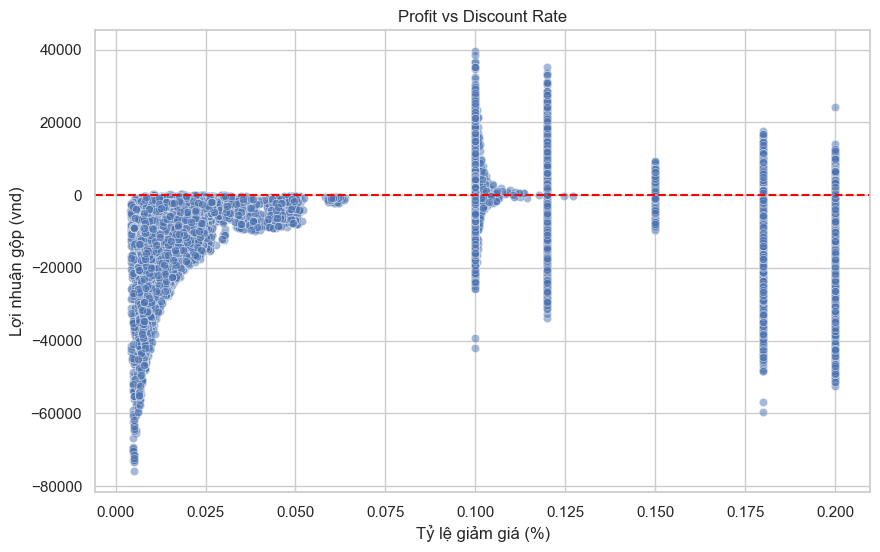

Mức giảm giá an toàn trung bình: 14.13%


In [41]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
sns.scatterplot(data=items[items['promo_flag']==1], x='discount_rate', y='gross_profit', alpha=0.5)
plt.axhline(0, color='red', linestyle='--') 
plt.title('Profit vs Discount Rate')
plt.xlabel('Tỷ lệ giảm giá (%)')
plt.ylabel('Lợi nhuận gộp (vnd)')
plt.show()

safe_discount = items[(items['promo_flag']==1) & (items['gross_profit'] > 0)]['discount_rate'].mean()
print(f"Mức giảm giá an toàn trung bình: {safe_discount:.2%}")

In [42]:
df_loss = items[items['cogs'] > items['unit_price']][['price', 'unit_price', 'cogs']]
df_loss.head(5)

,price,unit_price,cogs
77,7240.102907,6747.15,6878.097762
2548,1341.312712,1274.04,1274.247076
3242,7240.102907,6815.42,6878.097762
3300,1109.261061,1045.43,1053.798008
4189,9014.516341,8538.57,8563.790524


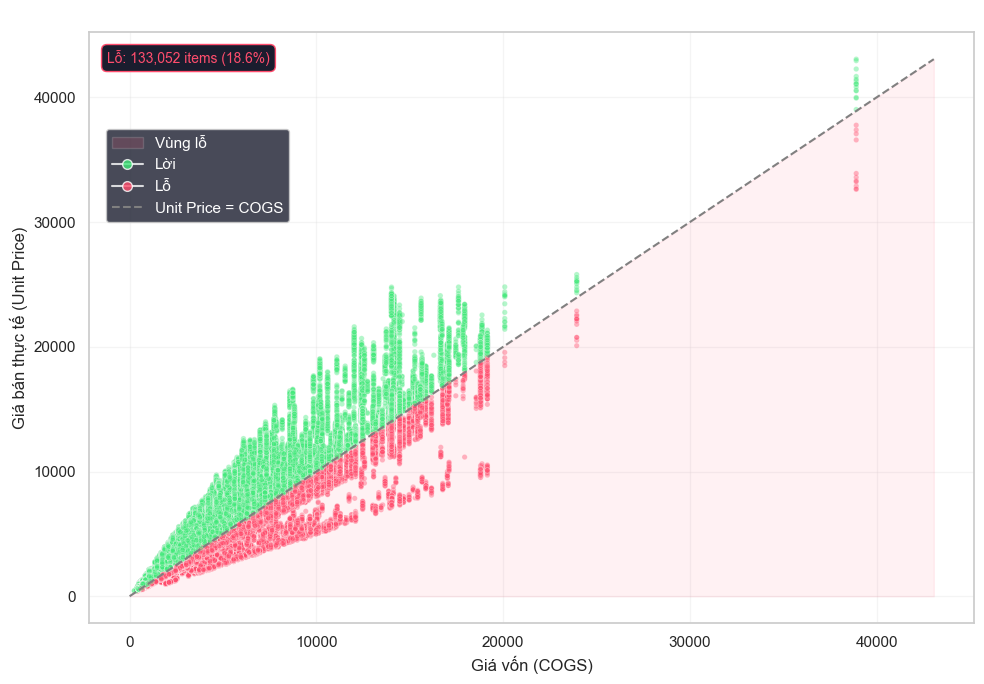

In [43]:
fig, ax = plt.subplots(figsize=(10, 7))
df_copy = items.copy()
df_copy['profit_status'] = np.where(df_copy['unit_price'] >= df_copy['cogs'], 'Lời', 'Lỗ')

max_val = max(df_copy['cogs'].max(), df_copy['unit_price'].max())

ax.fill_between([0, max_val], 0, [0, max_val], color=ACCENT, alpha=0.08)

sns.scatterplot(
    data=df_copy, x='cogs', y='unit_price',
    hue='profit_status',
    palette={'Lời': OK, 'Lỗ': ACCENT},
    alpha=0.4, s=15, ax=ax,
    legend=False          
)

ax.plot([0, max_val], [0, max_val], color='grey', linestyle='--',
        lw=1.5, zorder=5)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Patch(facecolor=ACCENT, alpha=0.15, label='Vùng lỗ'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=OK,
           markersize=7, label='Lời', alpha=0.8),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=ACCENT,
           markersize=7, label='Lỗ', alpha=0.8),
    Line2D([0],[0], color='grey', linestyle='--', lw=1.5, label='Unit Price = COGS'),
]
ax.legend(handles=handles, facecolor='#1a1d2e', labelcolor='white',
          loc='upper left', bbox_to_anchor=(0.01, 0.85))  # đẩy xuống tránh text box

n_loss = (df_copy['profit_status'] == 'Lỗ').sum()
n_total = len(df_copy)
ax.text(0.02, 0.97,
        f'Lỗ: {n_loss:,} items ({n_loss/n_total*100:.1f}%)',
        transform=ax.transAxes, fontsize=10,
        color=ACCENT, va='top',
        bbox=dict(facecolor='#1a1d2e', edgecolor=ACCENT, boxstyle='round,pad=0.4'))

ax.set_title('Unit Price vs COGS — The Loss Zone', color='white', fontsize=13)
ax.set_xlabel('Giá vốn (COGS)')
ax.set_ylabel('Giá bán thực tế (Unit Price)')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('loss_zone_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

In [44]:
df_fail = items[items['cogs'] > items['unit_price']][items['promo_flag']==0]

overall = {
    'gross_demand':  df_fail['gross_demand'].sum(),
    'net_revenue':   df_fail['net_revenue'].sum(),
    'total_cogs':    df_fail['total_cogs'].sum(),
    'discount_amt':  df_fail['discount_amount'].sum(),
    'gross_profit':  df_fail['gross_profit'].sum(),
}
overall['margin_pct'] = overall['gross_profit'] / overall['net_revenue']

print(f'Items bán dưới giá vốn (không có KM): {len(df_fail):,}')
print(f'Gross profit: {df_fail["gross_profit"].sum():,.0f}')

pd.DataFrame([overall]).style.format({
    'gross_demand': '{:,.0f}', 'net_revenue': '{:,.0f}',
    'total_cogs':   '{:,.0f}', 'discount_amt':'{:,.0f}',
    'gross_profit': '{:,.0f}', 'margin_pct':  '{:.2%}'
})

Items bán dưới giá vốn (không có KM): 808
Gross profit: -137,149


,gross_demand,net_revenue,total_cogs,discount_amt,gross_profit,margin_pct
0,"19,429,538","19,429,538","19,566,687",0,"-137,149",-0.71%


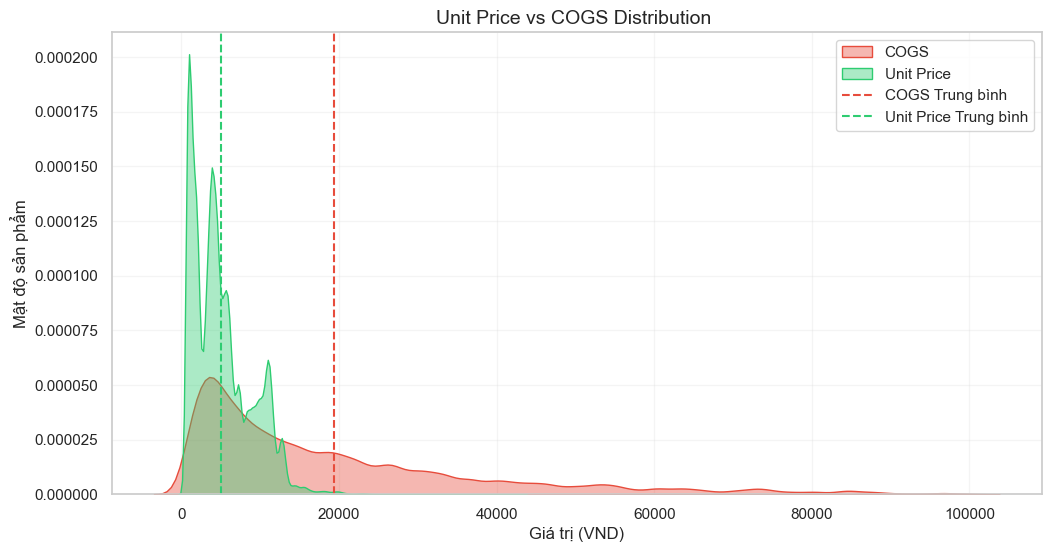

In [45]:
df_sub = items[items['total_cogs'] < 100000].copy()

plt.figure(figsize=(12, 6))

sns.kdeplot(data=df_sub, x='total_cogs', fill=True, color='#e74c3c', label='COGS', alpha=0.4)

sns.kdeplot(data=df_sub, x='unit_price', fill=True, color='#2ecc71', label='Unit Price', alpha=0.4)

plt.axvline(df_sub['total_cogs'].mean(), color='#e74c3c', linestyle='--', label='COGS Trung bình')
plt.axvline(df_sub['unit_price'].mean(), color='#2ecc71', linestyle='--', label='Unit Price Trung bình')

plt.title('Unit Price vs COGS Distribution ', fontsize=14)
plt.xlabel('Giá trị (VND)')
plt.ylabel('Mật độ sản phẩm')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

**Phân tích phân phối cho thấy một nghịch lý tài chính nghiêm trọng**:

Hiện tượng: Giá bán thực tế (Unit Price) tập trung ở ngưỡng cực thấp, trong khi Giá vốn (COGS) phân bổ ở ngưỡng cao hơn gấp nhiều lần.

Nguyên nhân: Đây là hệ quả của việc định giá gốc (Base Pricing) sai lệch hoàn toàn so với chi phí nhập hàng, làm cho sản phẩm chưa áp dụng giảm giá đã được bán thấp hơn giá gốc, gây lỗ cho doanh nghiệp
Nguyên nhân gây lỗ không chỉ xuất phát từ promotion

### **Các nguyên nhân khác**

In [46]:
# ── Bước 1: Identify sản phẩm có unit_price < cogs ──
underpriced = items[items['unit_price'] < items['cogs']].copy()
underpriced['loss_per_unit'] = underpriced['cogs'] - underpriced['unit_price']
underpriced['loss_total']    = underpriced['loss_per_unit'] * underpriced['quantity']

print(f'Số line items bán dưới giá vốn : {len(underpriced):,}')
print(f'Tỷ lệ                          : {len(underpriced)/len(items):.2%}')
print(f'Tổng lỗ từ nhóm này            : {underpriced["loss_total"].sum():,.0f} VND')
print(f'Margin trung bình              : {underpriced["gross_profit"].sum()/underpriced["net_revenue"].sum():.2%}')

# ── Bước 2: Phân tích theo category và segment ──
print('\n=== UNDERPRICED BY CATEGORY ===')
cat_under = underpriced.groupby('category').agg(
    num_items      = ('order_id',       'size'),
    loss_total     = ('loss_total',     'sum'),
    avg_loss_unit  = ('loss_per_unit',  'mean'),
    avg_unit_price = ('unit_price',     'mean'),
    avg_cogs       = ('cogs',           'mean'),
).assign(
    cogs_ratio = lambda d: d['avg_cogs'] / d['avg_unit_price'],
    pct_of_cat = lambda d: d['num_items'] / underpriced.groupby('category').size().sum()
).sort_values('loss_total', ascending=False)

cat_under.style.format({
    'num_items':     '{:,.0f}',
    'loss_total':    '{:,.0f}',
    'avg_loss_unit': '{:,.0f}',
    'avg_unit_price':'{:,.0f}',
    'avg_cogs':      '{:,.0f}',
    'cogs_ratio':    '{:.2f}x',
    'pct_of_cat':    '{:.2%}',
})

Số line items bán dưới giá vốn : 133,052
Tỷ lệ                          : 18.62%
Tổng lỗ từ nhóm này            : 461,536,686 VND
Margin trung bình              : -34.60%

=== UNDERPRICED BY CATEGORY ===


,num_items,loss_total,avg_loss_unit,avg_unit_price,avg_cogs,cogs_ratio,pct_of_cat
category,,,,,,,
Streetwear,"80,711","408,802,189","1,124","6,244","7,368",1.18x,60.66%
Outdoor,"43,603","41,047,155",209,"2,045","2,254",1.10x,32.77%
Casual,"5,209","8,219,813",359,"3,506","3,865",1.10x,3.92%
GenZ,"3,529","3,467,528",222,"2,313","2,535",1.10x,2.65%


In [47]:
df_orders[['order_id','order_date']]

,order_id,order_date
0,1,2012-07-04
1,2,2012-07-04
2,3,2012-07-04
3,4,2012-07-04
4,6,2012-07-06
...,...,...
646940,834372,2022-12-31
646941,834377,2022-12-31
646942,834387,2022-12-31
646943,834392,2022-12-31


In [48]:
# # 1. Đảm bảo order_date đúng định dạng
# df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# # 2. Merge và tính toán theo năm
# time_underprice = underpriced.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')
# time_underprice['order_year'] = time_underprice['order_date'].dt.year

# 3. Tổng hợp dữ liệu
yearly_summary = underpriced.groupby('year').agg(
    num_items      = ('order_id',       'size'),
    loss_total     = ('loss_total',     'sum'),
    avg_loss_unit  = ('loss_per_unit',  'mean'),
    avg_unit_price = ('unit_price',     'mean'),
    avg_cogs       = ('cogs',           'mean'),
).assign(
    cogs_ratio = lambda d: d['avg_cogs'] / d['avg_unit_price'],
    pct_of_total_loss_items = lambda d: d['num_items'] / len(underpriced) 
).sort_values('year')

# 4. Hiển thị bảng đẹp để copy vào Doc
yearly_summary.style.format({
    'num_items':     '{:,.0f}',
    'loss_total':    '{:,.0f}',
    'avg_loss_unit': '{:,.0f}',
    'avg_unit_price':'{:,.0f}',
    'avg_cogs':      '{:,.0f}',
    'cogs_ratio':    '{:.2f}x',
    'pct_of_total_loss_items': '{:.2%}',
})

,num_items,loss_total,avg_loss_unit,avg_unit_price,avg_cogs,cogs_ratio,pct_of_total_loss_items
year,,,,,,,
2012,73,"9,700",29,"4,030","4,059",1.01x,0.05%
2013,"20,853","75,820,748",804,"3,704","4,508",1.22x,15.67%
2014,"14,912","25,911,055",386,"3,997","4,384",1.10x,11.21%
2015,"20,441","80,802,486",873,"4,142","5,016",1.21x,15.36%
2016,"13,763","29,541,183",479,"4,897","5,376",1.10x,10.34%
2017,"19,274","84,927,167",981,"4,576","5,556",1.21x,14.49%
2018,"10,636","22,837,218",477,"5,006","5,483",1.10x,7.99%
2019,"10,739","53,224,632","1,090","4,884","5,974",1.22x,8.07%
2020,"6,152","15,549,546",563,"5,895","6,458",1.10x,4.62%


In [49]:
print('\n=== UNDERPRICED BY PRODUCT ===')
cat_under = underpriced.groupby('product_id').agg(
    num_items      = ('order_id',       'size'),
    loss_total     = ('loss_total',     'sum'),
    avg_loss_unit  = ('loss_per_unit',  'mean'),
    avg_unit_price = ('unit_price',     'mean'),
    avg_cogs       = ('cogs',           'mean'),
).assign(
    cogs_ratio = lambda d: d['avg_cogs'] / d['avg_unit_price'],
    pct_of_prod = lambda d: d['num_items'] / underpriced.groupby('category').size().sum()
).sort_values('loss_total', ascending=False)[:15]

cat_under.style.format({
    'num_items':     '{:,.0f}',
    'loss_total':    '{:,.0f}',
    'avg_loss_unit': '{:,.0f}',
    'avg_unit_price':'{:,.0f}',
    'avg_cogs':      '{:,.0f}',
    'cogs_ratio':    '{:.2f}x',
    'pct_of_prod':    '{:.2%}',
})


=== UNDERPRICED BY PRODUCT ===


,num_items,loss_total,avg_loss_unit,avg_unit_price,avg_cogs,cogs_ratio,pct_of_prod
product_id,,,,,,,
826,"2,446","20,019,265","1,823","10,271","12,094",1.18x,1.84%
491,"2,022","14,096,189","1,572","8,935","10,507",1.18x,1.52%
506,"1,337","12,514,532","2,137","12,326","14,463",1.17x,1.00%
487,"1,595","12,210,579","1,624","9,404","11,028",1.17x,1.20%
927,"2,704","11,164,727",916,"4,651","5,567",1.20x,2.03%
2054,"2,088","9,336,517","1,009","5,709","6,718",1.18x,1.57%
2055,"1,825","8,688,560","1,067","5,811","6,878",1.18x,1.37%
551,"1,096","8,631,906","1,715","8,968","10,683",1.19x,0.82%
407,665,"8,308,837","2,715","16,075","18,790",1.17x,0.50%


In [50]:
print('=== UNDERPRICED: PROMO vs NON-PROMO ===')
under_promo = underpriced.groupby('promo_flag').agg(
    num_items  = ('order_id',    'size'),
    loss_total = ('loss_total',  'sum'),
).rename(index={0:'No Promo', 1:'Promo'})
under_promo['pct'] = under_promo['num_items'] / under_promo['num_items'].sum()
display(under_promo.style.format({
    'num_items': '{:,.0f}', 'loss_total': '{:,.0f}', 'pct': '{:.2%}'
}))

=== UNDERPRICED: PROMO vs NON-PROMO ===


,num_items,loss_total,pct
promo_flag,,,
No Promo,808,"137,149",0.61%
Promo,"132,244","461,399,537",99.39%


In [51]:
# Xem xu hướng theo năm
print('=== UNDERPRICED TREND BY YEAR ===')
underpriced.groupby('year').agg(
    num_items  = ('order_id',   'size'),
    loss_total = ('loss_total', 'sum'),
).assign(
    pct_of_year = lambda d: d['num_items'] / items.groupby('year').size()
).style.format({
    'num_items':   '{:,.0f}',
    'loss_total':  '{:,.0f}',
    'pct_of_year': '{:.2%}',
})

=== UNDERPRICED TREND BY YEAR ===


,num_items,loss_total,pct_of_year
year,,,
2012,73,"9,700",0.20%
2013,"20,853","75,820,748",23.88%
2014,"14,912","25,911,055",16.37%
2015,"20,441","80,802,486",22.09%
2016,"13,763","29,541,183",15.14%
2017,"19,274","84,927,167",23.03%
2018,"10,636","22,837,218",14.16%
2019,"10,739","53,224,632",23.90%
2020,"6,152","15,549,546",16.52%


In [52]:
# Check min_order_value 
items_with_min = items.merge(
    df_promotions[['promo_id','min_order_value']], on='promo_id', how='left'
)
bypass = items_with_min[
    (items_with_min['min_order_value'] > 0) &
    (items_with_min['gross_demand'] < items_with_min['min_order_value'])
]

In [53]:
print(f"Số items applied promotion có min_order_value > 0: {(items_with_min['min_order_value'] > 0).sum():,}")
print(f"Số items chưa đủ min_order_value nhưng vẫn được áp dụng mã giảm giá: {len(bypass):,}")
print(f"Bypass rate: {len(bypass)/(items_with_min['min_order_value'] > 0).sum():.2%}")
print(f"Gross profit của của items applied mã giảm giá khi chưa đủ điều kiện: {bypass['gross_profit'].sum():,.0f}")
print(f"Margin của bypass items: {bypass['gross_profit'].sum()/bypass['net_revenue'].sum():.2%}")

# Xem bypass theo từng promo
bypass_by_promo = (
    bypass.merge(df_promotions[['promo_id','promo_name','promo_type','discount_value','min_order_value']], 
                 on='promo_id', how='left')
    .groupby(['promo_id','promo_name','promo_type','discount_value','min_order_value_y'])
    .agg(
        num_bypass   = ('order_id',     'size'),
        gross_profit = ('gross_profit', 'sum'),
        avg_order_val= ('gross_demand', 'mean'),
        net_revenue = ('net_revenue', 'sum')
    )
    .assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])
    .sort_values('num_bypass', ascending=False)
    .reset_index()
)
print('\n=== BYPASS BY PROMO ===')
bypass_by_promo.style.format({
    'num_bypass':   '{:,.0f}',
    'gross_profit': '{:,.0f}',
    'avg_order_val':'{:,.0f}',
    'min_order_value_y': '{:,.0f}',
})

Số items applied promotion có min_order_value > 0: 112,544
Số items chưa đủ min_order_value nhưng vẫn được áp dụng mã giảm giá: 110,896
Bypass rate: 98.54%
Gross profit của của items applied mã giảm giá khi chưa đủ điều kiện: -385,183,667
Margin của bypass items: -22.94%

=== BYPASS BY PROMO ===


,promo_id,promo_name,promo_type,discount_value,min_order_value_y,num_bypass,gross_profit,avg_order_val,net_revenue,margin_pct
0,PROMO-0014,Year-End Sale 2015,percentage,20.000000,"150,000","11,451","-29,591,013","12,875",117948745.460000,-0.250880
1,PROMO-0010,Year-End Sale 2014,percentage,20.000000,"100,000","11,332","-25,903,726","12,235",110917693.200000,-0.233540
2,PROMO-0004,Year-End Sale 2013,percentage,20.000000,"50,000","10,673","-18,227,926","9,239",78887917.540000,-0.231061
3,PROMO-0011,Spring Sale 2015,percentage,12.000000,"100,000","9,582","-3,553,516","20,753",174996173.870000,-0.020306
4,PROMO-0028,Mid-Year Sale 2018,percentage,18.000000,"150,000","8,144","-24,912,204","21,043",140529540.330000,-0.177274
5,PROMO-0022,Mid-Year Sale 2017,percentage,18.000000,"150,000","7,506","-25,700,027","21,903",134811268.620000,-0.190637
6,PROMO-0027,Spring Sale 2018,percentage,12.000000,"100,000","7,495","-3,263,744","22,221",146558703.150000,-0.022269
7,PROMO-0009,Fall Launch 2014,percentage,10.000000,"100,000","5,630","2,563,026","20,060",101644678.860000,0.025216
8,PROMO-0025,Urban Blowout 2017,fixed,50.000000,"150,000","5,385","-57,547,467","17,330",92111084.690000,-0.624762
9,PROMO-0015,Urban Blowout 2015,fixed,50.000000,"200,000","5,072","-53,201,221","16,744",83770839.850000,-0.635080


In [54]:
double_promo = items[items['promo_id'].notna() & items['promo_id_2'].notna()]
print(f'Items dùng 2 promo: {len(double_promo):,} ({len(double_promo)/len(items)*100:.3f}%)')
print(f'Gross profit: {double_promo["gross_profit"].sum():,.0f}')
print(f'Margin: {double_promo["gross_profit"].sum()/double_promo["net_revenue"].sum():.2%}')

Items dùng 2 promo: 206 (0.029%)
Gross profit: 116,605
Margin: 2.06%


In [55]:
double_promo_detail = (
    items[items['promo_id'].notna() & items['promo_id_2'].notna()]
    .merge(df_promotions[['promo_id','promo_name','discount_value']].rename(
        columns={'promo_id':'promo_id','promo_name':'name_p1','discount_value':'disc_p1'}), 
        on='promo_id', how='left')
    .merge(df_promotions[['promo_id','promo_name','discount_value']].rename(
        columns={'promo_id':'promo_id_2','promo_name':'name_p2','discount_value':'disc_p2'}), 
        on='promo_id_2', how='left')
    .groupby(['name_p1','name_p2'])
    .agg(
        num_items    = ('order_id',     'size'),
        gross_profit = ('gross_profit', 'sum'),
        net_revenue  = ('net_revenue',  'sum'),
    )
    .assign(margin_pct = lambda d: d['gross_profit'] / d['net_revenue'])
    .sort_values('num_items', ascending=False)
)
display(double_promo_detail)

,,num_items,gross_profit,net_revenue,margin_pct
name_p1,name_p2,,,,
Fall Launch 2015,Urban Blowout 2015,132,-46739.656096,3454678.53,-0.013529
Fall Launch 2017,Urban Blowout 2017,74,163345.120288,2206610.47,0.074025


In [56]:
check = items[items['promo_id'].notna() & items['promo_id_2'].notna()] \
    .merge(df_promotions[['promo_id','promo_name','discount_value','stackable_flag']].rename(
        columns={'promo_id':'promo_id','promo_name':'name_p1','discount_value':'disc_p1','stackable_flag': 'flag_1'}), 
        on='promo_id', how='left') \
    .merge(df_promotions[['promo_id','promo_name','discount_value','stackable_flag']].rename( 
        columns={'promo_id':'promo_id_2','promo_name':'name_p2','discount_value':'disc_p2','stackable_flag': 'flag_2'}), 
        on='promo_id_2', how='left')
error_promo = check[(check['flag_1']==0) |  (check['flag_2']==0)].shape[0]
print(f"Số lượng items giảm giá áp dụng 2 mã khuyến mãi dù ko được phép: {error_promo} - {error_promo/double_promo.shape[0]*100}%")

Số lượng items giảm giá áp dụng 2 mã khuyến mãi dù ko được phép: 206 - 100.0%


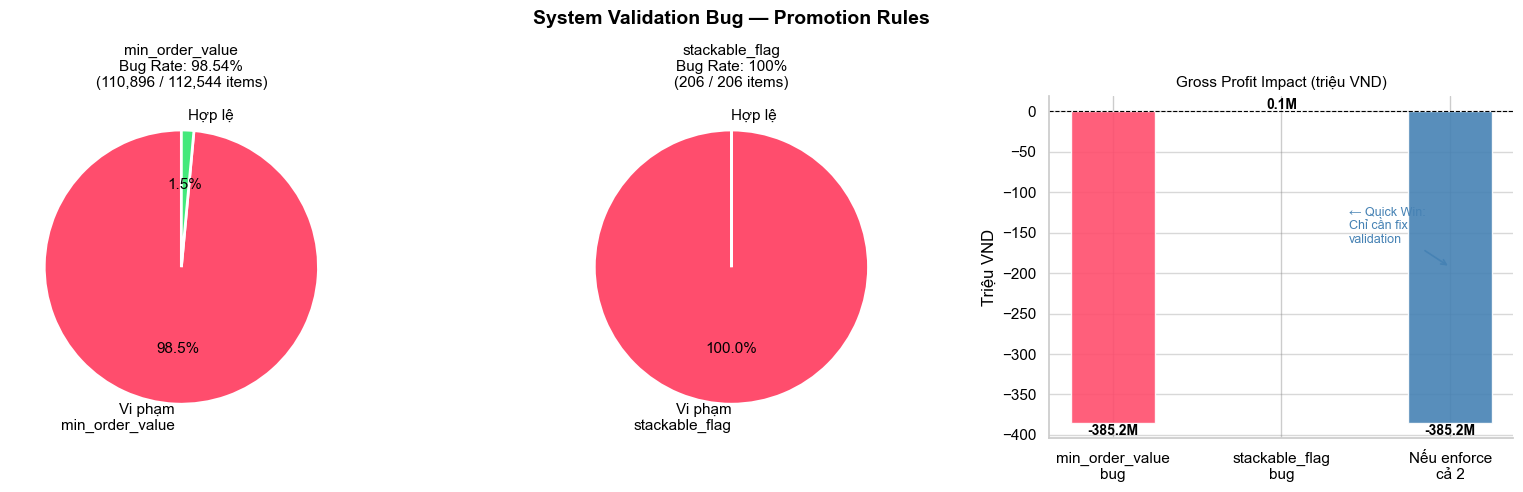

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('white')
fig.suptitle('System Validation Bug — Promotion Rules', 
             fontsize=14, color='black', fontweight='bold')

for ax in axes:
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)

# ── Chart 1: min_order_value bypass rate ──
ax = axes[0]
total_with_min = (items_with_min['min_order_value'] > 0).sum()
bypassed       = len(bypass)
valid          = total_with_min - bypassed

ax.pie(
    [bypassed, valid],
    labels=['Vi phạm\nmin_order_value', 'Hợp lệ'],
    colors=[ACCENT, OK],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'color': 'black', 'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax.set_title(f'min_order_value\nBug Rate: 98.54%\n({bypassed:,} / {total_with_min:,} items)', 
             color='black', fontsize=11)

# ── Chart 2: stackable_flag violation ──
ax2 = axes[1]
total_double   = len(double_promo)
valid_stack    = 0   
violated_stack = len(double_promo)

ax2.pie(
    [violated_stack, valid_stack + 0.001],  
    labels=['Vi phạm\nstackable_flag', 'Hợp lệ'],
    colors=[ACCENT, OK],
    autopct=lambda p: f'{p:.1f}%' if p > 1 else '',
    startangle=90,
    textprops={'color': 'black', 'fontsize': 11},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
ax2.set_title(f'stackable_flag\nBug Rate: 100%\n({total_double:,} / {total_double:,} items)', 
              color='black', fontsize=11)

# ── Chart 3: Gross Profit impact ──
ax3 = axes[2]
categories_bug = ['min_order_value\nbug', 'stackable_flag\nbug', 'Nếu enforce\ncả 2']
values = [
    bypass['gross_profit'].sum() / 1e6,
    double_promo['gross_profit'].sum() / 1e6,   # positive, nhỏ
    bypass['gross_profit'].sum() / 1e6,          # conservative: chỉ tính min_order
]
colors_bar = [ACCENT, OK, 'steelblue']
bars = ax3.bar(categories_bug, values, color=colors_bar, alpha=0.9, width=0.5)
ax3.axhline(0, color='black', lw=0.8, linestyle='--')
ax3.set_title('Gross Profit Impact (triệu VND)', color='black', fontsize=11)
ax3.set_ylabel('Triệu VND', color='black')
ax3.tick_params(colors='black')
ax3.grid(axis='y', alpha=0.3, color='gray')

for bar, val in zip(bars, values):
    y_pos = val - 15 if val < 0 else val + 3
    ax3.text(bar.get_x() + bar.get_width()/2, y_pos,
             f'{val:,.1f}M', ha='center', color='black', fontsize=10, fontweight='bold')

# Annotation "Quick Win"
ax3.annotate('← Quick Win:\nChỉ cần fix\nvalidation',
             xy=(2, values[2]/2),
             xytext=(1.4, values[2]/2 + 30),
             fontsize=9, color='steelblue',
             arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))

plt.tight_layout()
plt.show()

#### **SYSTEM VALIDATION BUG — SUMMARY**

*min_order_value không enforce |*
- bypassed items vi phạm / {total_with_min:,} items có điều kiện
- Bypass rate  : 98.54%
- Gross profit: -385,183,667 VND
- Margin: -22.94%
-------------------------------------------------------

*stackable_flag không enforce |*
- 206 items vi phạm / 206 items dùng 2 promo
- Violation rate : 100%
- Thiệt hại hiện tại : nhỏ (+2.06% margin)
- Rủi ro : nếu bị exploit với toxic promo → nguy hiểm

-------------------------------------------------------

*FIX |*
- Bật validation ở backend → recover ~385M gross profit
- Không cần thay đổi promotion strategy

=======================================================

## II.3. Khám phá độ hiệu quả của các Promotion Campaign

In [58]:
# Tập trung vào item-level để xem mã này mang lại bao nhiêu lãi thực tế và do promotion chỉ được áp dụng trên level item thôi
## Xét trên promo_id, coi như promo_id_2 chỉ là adds on, ko cân nhắc là promotion chính
promo_items = items[items['promo_id'].notna()][
    ['promo_id', 'net_revenue', 'discount_amount', 'gross_profit', 'total_cogs']
].copy()

promo_performance = promo_items.groupby('promo_id').agg(
    num_items      = ('promo_id',       'size'),
    discount_sum   = ('discount_amount','sum'),
    net_revenue    = ('net_revenue',    'sum'),
    total_cogs     = ('total_cogs',     'sum'),
    gross_profit   = ('gross_profit',   'sum'),
).assign(
    margin_pct = lambda d: d['gross_profit'] / d['net_revenue'],
    # ROI -> 1 đồng discount bỏ ra thu về bao nhiêu đồng lợi nhuận gộp
    roi = lambda d: d['gross_profit'] / d['discount_sum'],
)

top10_profitable = promo_performance.reset_index().merge(
    df_promotions[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'min_order_value']],
    on='promo_id', 
    how='left'
).sort_values('gross_profit', ascending=False).head(10)

print('=== TOP 10 MOST PROFITABLE PROMOS (Lãi cao nhất) ===')
top10_profitable[['promo_id', 'promo_name', 'promo_type', 'discount_value', 
                  'num_items', 'discount_sum', 'net_revenue', 'gross_profit', 'margin_pct', 'roi']].style.format({
    'discount_value': '{:.1f}', 'num_items':   '{:,.0f}',
    'discount_sum':   '{:,.0f}', 'net_revenue': '{:,.0f}',
    'gross_profit':   '{:,.0f}', 'margin_pct':  '{:.2%}',
    'roi':            '{:.2f}'
}).background_gradient(cmap='Greens', subset=['gross_profit', 'margin_pct', 'roi'])

=== TOP 10 MOST PROFITABLE PROMOS (Lãi cao nhất) ===


,promo_id,promo_name,promo_type,discount_value,num_items,discount_sum,net_revenue,gross_profit,margin_pct,roi
8,PROMO-0009,Fall Launch 2014,percentage,10.0,"5,637","11,376,285","102,386,562","2,530,603",2.47%,0.22
28,PROMO-0029,Fall Launch 2018,percentage,10.0,"4,328","11,505,517","103,549,648","2,031,417",1.96%,0.18
22,PROMO-0023,Fall Launch 2017,percentage,10.0,"5,413","12,908,025","116,135,215","1,944,308",1.67%,0.15
32,PROMO-0033,Fall Launch 2019,percentage,10.0,"3,101","8,082,957","72,746,607","1,603,420",2.20%,0.20
12,PROMO-0013,Fall Launch 2015,percentage,10.0,"7,498","15,286,980","137,516,810","1,385,018",1.01%,0.09
2,PROMO-0003,Fall Launch 2013,percentage,10.0,"6,277","13,029,490","117,265,399","1,252,607",1.07%,0.10
18,PROMO-0019,Fall Launch 2016,percentage,10.0,"5,763","13,562,953","122,066,567","403,896",0.33%,0.03
38,PROMO-0039,Fall Launch 2020,percentage,10.0,"2,593","7,579,386","68,214,467","361,015",0.53%,0.05
45,PROMO-0046,Rural Special 2021,percentage,15.0,588,"1,096,586","6,213,991","-534,771",-8.61%,-0.49
35,PROMO-0036,Rural Special 2019,percentage,15.0,"1,082","1,749,959","9,916,436","-787,822",-7.94%,-0.45


In [59]:
top10_loss = promo_performance.reset_index().merge(
    df_promotions[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'min_order_value']],
    on='promo_id', 
    how='left'
).sort_values('gross_profit').head(10)

print('=== TOP 10 MOST LOSSED PROMOS (Lỗ nặng nhất) ===')
top10_loss[['promo_id', 'promo_name', 'promo_type', 'discount_value', 
                  'num_items', 'discount_sum', 'net_revenue', 'gross_profit', 'margin_pct', 'roi']].style.format({
    'discount_value': '{:.1f}', 'num_items':   '{:,.0f}',
    'discount_sum':   '{:,.0f}', 'net_revenue': '{:,.0f}',
    'gross_profit':   '{:,.0f}', 'margin_pct':  '{:.2%}',
    'roi':            '{:.2f}'
}).background_gradient(cmap='Reds', subset=['gross_profit', 'margin_pct', 'roi'])

=== TOP 10 MOST LOSSED PROMOS (Lỗ nặng nhất) ===


,promo_id,promo_name,promo_type,discount_value,num_items,discount_sum,net_revenue,gross_profit,margin_pct,roi
24,PROMO-0025,Urban Blowout 2017,fixed,50.0,"5,385","1,212,300","92,111,085","-57,547,467",-62.48%,-47.47
14,PROMO-0015,Urban Blowout 2015,fixed,50.0,"5,072","1,152,650","83,770,840","-53,201,221",-63.51%,-46.16
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,"4,887","1,102,400","80,919,592","-51,274,871",-63.37%,-46.51
34,PROMO-0035,Urban Blowout 2019,fixed,50.0,"3,174","715,400","61,791,470","-37,173,084",-60.16%,-51.96
44,PROMO-0045,Urban Blowout 2021,fixed,50.0,"2,432","543,800","53,154,205","-36,060,649",-67.84%,-66.31
13,PROMO-0014,Year-End Sale 2015,percentage,20.0,"11,451","29,487,186","117,948,745","-29,591,013",-25.09%,-1.00
19,PROMO-0020,Year-End Sale 2016,percentage,20.0,"10,121","29,191,426","116,765,707","-28,309,833",-24.24%,-0.97
9,PROMO-0010,Year-End Sale 2014,percentage,20.0,"11,345","28,014,218","112,056,872","-26,173,971",-23.36%,-0.93
21,PROMO-0022,Mid-Year Sale 2017,percentage,18.0,"7,506","29,592,717","134,811,269","-25,700,027",-19.06%,-0.87
27,PROMO-0028,Mid-Year Sale 2018,percentage,18.0,"8,146","30,906,414","140,795,890","-25,028,847",-17.78%,-0.81


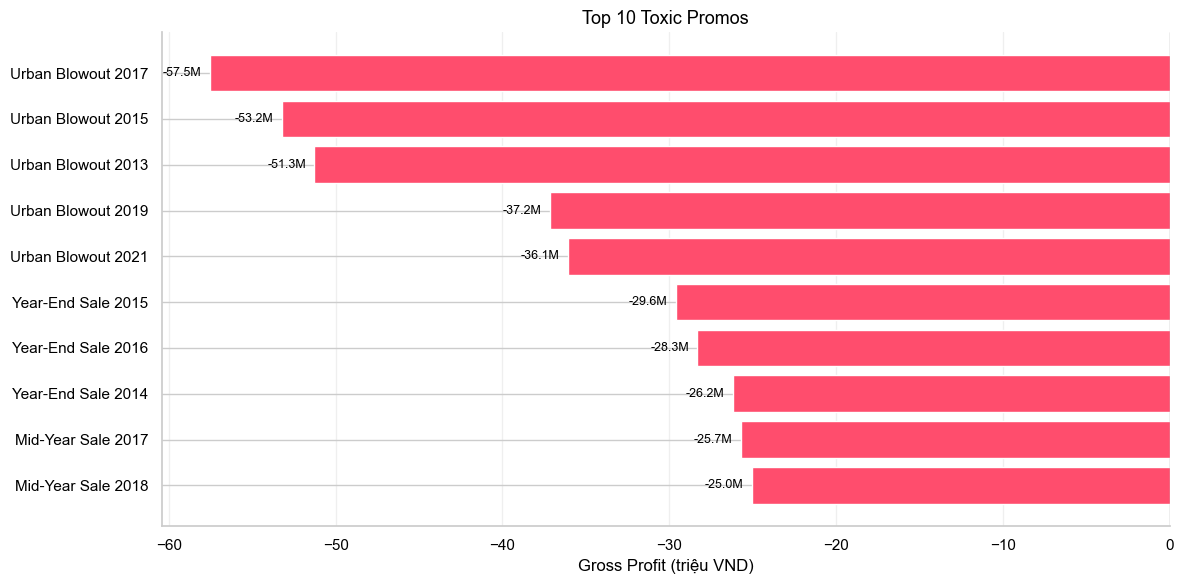

In [60]:
top10_loss = promo_performance.reset_index().merge(
    df_promotions[['promo_id', 'promo_name', 'promo_type', 'discount_value', 'min_order_value']],
    on='promo_id', 
    how='left'
).sort_values('gross_profit').head(10)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
top10_plot = top10_loss.set_index('promo_name')['gross_profit'] / 1e6
colors = [ACCENT if v < 0 else OK for v in top10_plot]
bars = ax.barh(top10_plot.index, top10_plot.values, color=colors)
ax.axvline(0, color='black', lw=0.8)
for bar, val in zip(bars, top10_plot.values):
    ax.text(val - 0.5, bar.get_y()+bar.get_height()/2,
            f'{val:,.1f}M', va='center', ha='right', color='black', fontsize=9)
ax.set_title('Top 10 Toxic Promos', color='black', fontsize=13)
ax.set_xlabel('Gross Profit (triệu VND)', color='black')
ax.tick_params(colors='black')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('top10_toxic_promos.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [61]:
promo_meta = df_promotions[['promo_id','promo_type','discount_value','stackable_flag','min_order_value']]

items_type = items.merge(promo_meta,
                         left_on='promo_id', right_on='promo_id', how='left')

type_summary = (
    items_type[items_type['promo_flag']==1]
    .groupby('promo_type').agg(
        num_items     = ('order_id',        'size'),
        net_revenue   = ('net_revenue',     'sum'),
        discount_sum  = ('discount_amount', 'sum'),
        gross_profit  = ('gross_profit',    'sum'),
        avg_disc_rate = ('discount_rate',   'mean'),
    ).assign(
        margin_pct = lambda d: d['gross_profit'] / d['net_revenue'],
        share_pct  = lambda d: d['num_items'] / d['num_items'].sum()
    )
)
print('=== PROMO TYPE COMPARISON ===')
type_summary.style.format({
    'num_items':'{:,.0f}','net_revenue':'{:,.0f}','discount_sum':'{:,.0f}',
    'gross_profit':'{:,.0f}','avg_disc_rate':'{:.2%}',
    'margin_pct':'{:.2%}','share_pct':'{:.2%}'
}).applymap(lambda x: 'color: #ff4d6d' if isinstance(x,float) and x<0 else '',
            subset=['gross_profit','margin_pct'])

=== PROMO TYPE COMPARISON ===


,num_items,net_revenue,discount_sum,gross_profit,avg_disc_rate,margin_pct,share_pct
promo_type,,,,,,,
fixed,"20,950","371,747,191","4,726,550","-235,257,291",1.59%,-63.28%,7.58%
percentage,"255,366","4,314,083,021","744,880,770","-442,339,348",15.35%,-10.25%,92.42%


Fixed promotion nên bị khai tử vì không mang lại hiệu quả đáng kể, dù được áp dụng trên ít items (1/10 so vớ percentage) nhưng biên lợi nhuận lại âm gấp 6 lần so với percentage promotion

## II.4. Customer segmentation

*Phân loại customer:*
  - Full-price Only: Chưa từng sử dụng KM khi mua hàng
  - Cherry-picker: Chỉ mua hàng khi có KM (không có đơn nào full-price)
  - Mixed.Loyal: Dùng khuyến mãi khi có dịp
  - Promo-leaning: Thường mua có KM nhiều hơn

In [62]:
def classify(row):
    if row['promo_orders'] == 0:
        return 'Full-price Only'
    elif row['fullprice_orders'] == 0:
        return 'Cherry-picker (Promo Only)'
    elif row['promo_orders'] >= row['fullprice_orders']:
        return 'Promo-leaning'   
    else:
        return 'Mixed / Loyal'  

In [63]:
cust_orders = items.rename(columns={'segment': 'prod_segment'}).copy()

cust_orders['customer_id'] = cust_orders['customer_id'].astype(int)

cust_profile = (
    cust_orders.groupby('customer_id').agg(
        total_orders  = ('order_id',   pd.Series.nunique),
        promo_orders  = ('promo_flag', 'sum'),
    )
    .assign(fullprice_orders = lambda d: d['total_orders'] - d['promo_orders'])
    .reset_index()
)

cust_profile['customer_id'] = cust_profile['customer_id'].astype(int)
cust_profile['cust_segment'] = cust_profile.apply(classify, axis=1)

In [64]:
seg_revenue = (
    cust_orders.merge(cust_profile[['customer_id','cust_segment']], on='customer_id', how='left')
    .groupby('cust_segment')
    .agg(
        net_revenue   = ('net_revenue',  'sum'),
        gross_profit  = ('gross_profit', 'sum'),
        num_customers = ('customer_id',  pd.Series.nunique),
    )
    .assign(
        rev_per_cust    = lambda d: d['net_revenue']  / d['num_customers'],
        profit_per_cust = lambda d: d['gross_profit'] / d['num_customers'],
        margin_pct      = lambda d: d['gross_profit'] / d['net_revenue'],
    )
)

seg_revenue.style.format({
    'net_revenue':    '{:,.0f}', 'gross_profit':   '{:,.0f}',
    'num_customers':  '{:,.0f}', 'rev_per_cust':   '{:,.0f}',
    'profit_per_cust':'{:,.0f}', 'margin_pct':     '{:.2%}'
}).map(lambda x: 'color: #ff4d6d' if isinstance(x, float) and x < 0 else '',
       subset=['gross_profit', 'margin_pct', 'profit_per_cust'])

,net_revenue,gross_profit,num_customers,rev_per_cust,profit_per_cust,margin_pct
cust_segment,,,,,,
Cherry-picker (Promo Only),"343,821,869","-34,783,176","11,268","30,513","-3,087",-10.12%
Full-price Only,"1,078,635,395","217,324,885","22,835","47,236","9,517",20.15%
Mixed / Loyal,"9,440,959,131","1,074,783,428","30,270","311,892","35,507",11.38%
Promo-leaning,"4,817,452,871","260,093,610","25,873","186,196","10,053",5.40%


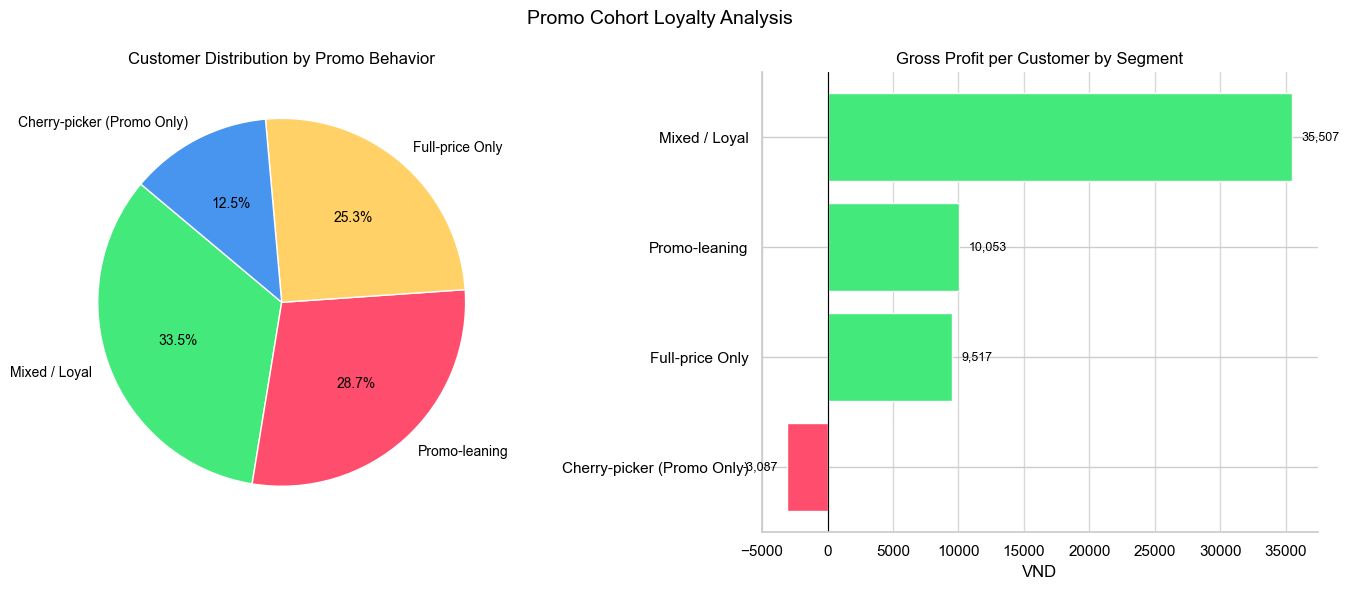

In [65]:
seg_counts = cust_profile['cust_segment'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')
fig.suptitle('Promo Cohort Loyalty Analysis', color='black', fontsize=14)

# Pie
ax = axes[0]
pie_colors = [OK, ACCENT, YELLOW, BLUE]
wedges, texts, autotexts = ax.pie(
    seg_counts.values, labels=seg_counts.index,
    autopct='%1.1f%%', colors=pie_colors[:len(seg_counts)],
    startangle=140, textprops={'color':'black', 'fontsize':10}
)
ax.set_title('Customer Distribution by Promo Behavior', color='black')

# Profit per customer bar
ax2 = axes[1]
ppc = seg_revenue['profit_per_cust'].sort_values()
bar_c = [OK if v > 0 else ACCENT for v in ppc]
bars = ax2.barh(ppc.index, ppc.values, color=bar_c)
ax2.set_facecolor('white')
ax2.axvline(0, color='black', lw=0.8)
ax2.tick_params(colors='black')
ax2.xaxis.label.set_color('black')
ax2.title.set_color('black')
for bar, val in zip(bars, ppc.values):
    x_pos = val + (ppc.max() * 0.02) if val >= 0 else val - (ppc.max() * 0.02)
    ha = 'left' if val >= 0 else 'right'
    ax2.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:,.0f}', va='center', ha=ha, color='black', fontsize=9)
ax2.set_title('Gross Profit per Customer by Segment', color='black')
ax2.set_xlabel('VND')
ax2.grid(axis='x', alpha=0.3, color='gray')
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('cohort_loyalty.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

1. Cherry-picker đang được doanh nghiệp "trợ cấp" — 11,268 khách này tạo ra -34.7M gross profit, tức là doanh nghiệp đang mất trung bình 3,087 VND cho mỗi lần họ mua hàng.
2. Full-price Only margin cao nhất (20.15%) nhưng rev/cust thấp — họ trung thành và profitable nhưng mua ít. Đây là nhóm cần được nurture, không phải chạy KM vào.
3. Mixed/Loyal là nhóm vàng — revenue/cust cao nhất (311,892), profit/cust cao nhất (35,507). Họ mua cả có và không có KM — Khuyến mãi với nhóm này ko phải là yếu tố họ quyết định mua hàngvì họ vẫn quay lại mua full-price.
Kết luận: Khuyến mãi đang thu hút sai đối tượng khách hàng — kéo Cherry-picker vào nhưng ko thể khiến họ họ thành Mixed/Loyal. Có thể thiết kế khuyến mãi có điều kiện (ví dụ: chỉ áp dụng cho khách đã có ít nhất 1 đơn chưa có khuyến mãi) để lọc bớt Cherry-picker.

In [66]:
cherry_dist = df_customers.merge(
    cust_profile[['customer_id','cust_segment']], on='customer_id'
).groupby(['acquisition_channel','cust_segment'])['customer_id'].count().unstack()
cherry_dist['total'] = cherry_dist.sum(axis=1)
cherry_dist['cherry_pct'] = (
    cherry_dist['Cherry-picker (Promo Only)'] /
    cherry_dist['total'] 
)
cherry_dist[['Cherry-picker (Promo Only)','cherry_pct', 'total']].style.format({
    'cherry_pct':    '{:.2%}',
    'total':     '{:.0f}'
}).map(lambda x: 'color: #ff4d6d' if isinstance(x, float) and x < 0 else '')
#cherry_dist[['cherry_pct', 'total']]

cust_segment,Cherry-picker (Promo Only),cherry_pct,total
acquisition_channel,,,
direct,915,12.47%,7337
email_campaign,1399,12.85%,10886
organic_search,3333,12.37%,26950
paid_search,2232,12.40%,17999
referral,1166,12.85%,9072
social_media,2223,12.35%,18002


Cherry-picker chiếm ~12–13% ở tất cả các kênh và không bị ảnh hưởng bởi acquisition channel. Điều này cho thấy đây là một hành vi khách hàng cố hữu, không phải do marketing channel gây ra. Vì vậy, chiến lược nên tập trung vào thiết kế khuyến mãi và pricing thay vì tối ưu kênh

In [67]:
# Return count theo promo_flag
returns_promo = df_returns.merge(
    items[['order_id','promo_flag']].drop_duplicates('order_id'),  
    on='order_id', how='left'
)

return_counts = returns_promo.groupby('promo_flag')['return_id'].count()

order_counts = items.groupby('promo_flag')['order_id'].nunique()

return_rate = return_counts / order_counts

print('=== RETURN RATE: Promo vs Non-Promo ===')
result = pd.DataFrame({
    'num_returns':  return_counts,
    'num_orders':   order_counts,
    'return_rate':  return_rate,
}).rename(index={0: 'No Promo', 1: 'Promo'})

result.style.format({
    'num_returns': '{:,.0f}',
    'num_orders':  '{:,.0f}',
    'return_rate': '{:.2%}',
}).map(lambda x: 'color: #ff4d6d' if isinstance(x, float) and x > 0.1 else '', 
       subset=['return_rate'])

=== RETURN RATE: Promo vs Non-Promo ===


,num_returns,num_orders,return_rate
promo_flag,,,
No Promo,"24,512","398,972",6.14%
Promo,"15,427","248,242",6.21%


Tỷ lệ trả hàng ở cả nhóm dùng khuyến mãi và không dùng khuyến mãi tương đương nhau nên lý do trả hàng không đến từ các đợt khuyến mãi mà do chất lượng sản phẩm hoặc nguyên nhân nào từ chính sản phẩm.

# III. Customer Journey Analysis

## III.1. Xu hướng doanh thu và lượt truy cập theo tháng

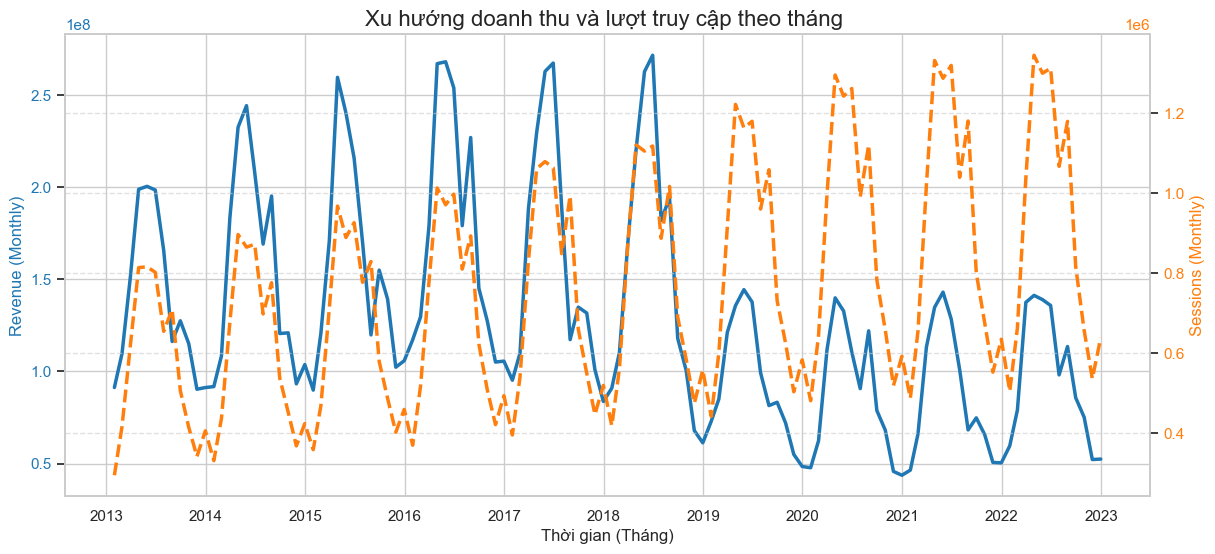

In [68]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])
df_sales_filtered = df_sales[df_sales['Date'] >= '2013-01-01'].copy()
df_sales_filtered = df_sales_filtered.set_index('Date')
df_traffic_indexed = df_web_traffic.groupby('date').agg({
    'sessions': 'sum',
    'unique_visitors': 'sum'
})

df_combined = df_sales_filtered.join(df_traffic_indexed, how='inner') # Dùng inner để đảm bảo ngày nào cũng có dữ liệu cả 2 bảng

df_monthly = df_combined.resample('M').agg({'Revenue': 'sum', 'sessions': 'sum'})


fig, ax1 = plt.subplots(figsize=(14, 6))

# Trục 1: Revenue
color = 'tab:blue'
ax1.set_xlabel('Thời gian (Tháng)')
ax1.set_ylabel('Revenue (Monthly)', color=color, fontsize=12)
ax1.plot(df_monthly.index, df_monthly['Revenue'], color=color, linewidth=2.5, label='Revenue')
ax1.tick_params(axis='y', labelcolor=color)

# Trục 2: Sessions
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Sessions (Monthly)', color=color, fontsize=12)
ax2.plot(df_monthly.index, df_monthly['sessions'], color=color, linestyle='--', linewidth=2.5, label='Sessions')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Xu hướng doanh thu và lượt truy cập theo tháng ', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [69]:
# Tính trung bình các chỉ số theo nguồn traffic
traffic_analysis = df_web_traffic.groupby('traffic_source').agg({
    'unique_visitors': 'sum',
    'bounce_rate': 'mean',
    'avg_session_duration_sec': 'mean'
})
print(traffic_analysis)

                unique_visitors  bounce_rate  avg_session_duration_sec
traffic_source                                                        
direct                  4986650     0.004511                207.678195
email_campaign          9700462     0.004458                213.220594
organic_search         20625107     0.004504                211.153945
paid_search            14922386     0.004478                209.362117
referral                7220019     0.004499                207.558667
social_media           12048065     0.004476                210.290190


Bounce rate (tỷ lệ thoát) là phần trăm số lượt truy cập website mà người dùng chỉ xem một trang duy nhất rồi rời đi mà không tương tác thêm (nhấp vào liên kết, điền form,...). 
-> thấp trang thu hút người xem

## III.2. Lượng khách truy cập và Tỷ lệ chuyển đổi theo năm

In [70]:
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
df_web_traffic['year'] = df_web_traffic['date'].dt.year

df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_orders['year'] = df_orders['order_date'].dt.year

# Orders theo năm
yearly_orders = df_orders.groupby('year')['order_id'].nunique()

# Visitors theo năm
yearly_visitors = df_web_traffic.groupby('year')['unique_visitors'].sum()

# Combine
df_cr_year = pd.DataFrame({
    'Orders': yearly_orders,
    'Visitors': yearly_visitors
}).fillna(0)

# CR
df_cr_year['Conversion_Rate'] = (df_cr_year['Orders'] / df_cr_year['Visitors']) * 100


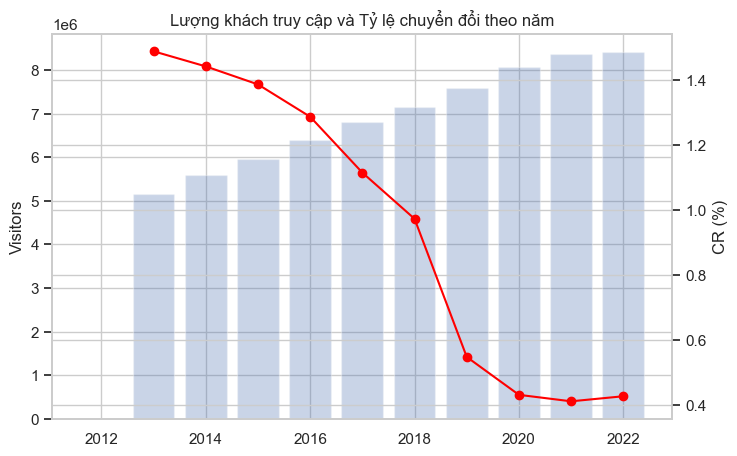

In [71]:
fig, ax1 = plt.subplots(figsize=(8,5))

# Bar: Visitors
ax1.bar(df_cr_year.index, df_cr_year['Visitors'], alpha=0.3)
ax1.set_ylabel('Visitors')

# Line: CR
ax2 = ax1.twinx()
ax2.plot(df_cr_year.index, df_cr_year['Conversion_Rate'], color='red', marker='o')
ax2.set_ylabel('CR (%)')

plt.title('Lượng khách truy cập và Tỷ lệ chuyển đổi theo năm')
plt.show()

Tại sao: Ngay khi thấy doanh thu giảm, câu hỏi đặt ra là : "Tại sao?". Biểu đồ này chứng minh rằng vấn đề nằm ở hiệu suất chuyển đổi (CR lao dốc).
Thông điệp: "Chúng ta không mất khách, chúng ta đánh mất khả năng thuyết phục họ mua hàng." Câu hỏi đặt ra là tại sao họ vẫn vô web để xem hàng nhưng không chuyển đổi thành lượt mua? (có thể do các kênh bán, chất lượng sản phẩm,... )

#### Giả thuyết đặt ra:

- Giả thuyết A (Traffic Quality): Lưu lượng truy cập đang bị"pha loãng" bởi các kênh tiếp thị kém chất lượng (kênh rác), gây lãng phí ngân sách mà không tạo ra doanh thu thực tế.

- Giả thuyết B (Customer Trust Decay):Các vấn đề về hàng lỗi (`defective items`) đã tích tụ theo thời gian, tạo ra "rào cản tâm lý" (invisible barrier) khiến khách hàng tiềm năng ngần ngại trước khi quyết định thanh toán.


1. Kiểm chứng Giả thuyết A (Traffic Quality)

    -  Kênh nào kéo CR xuống?

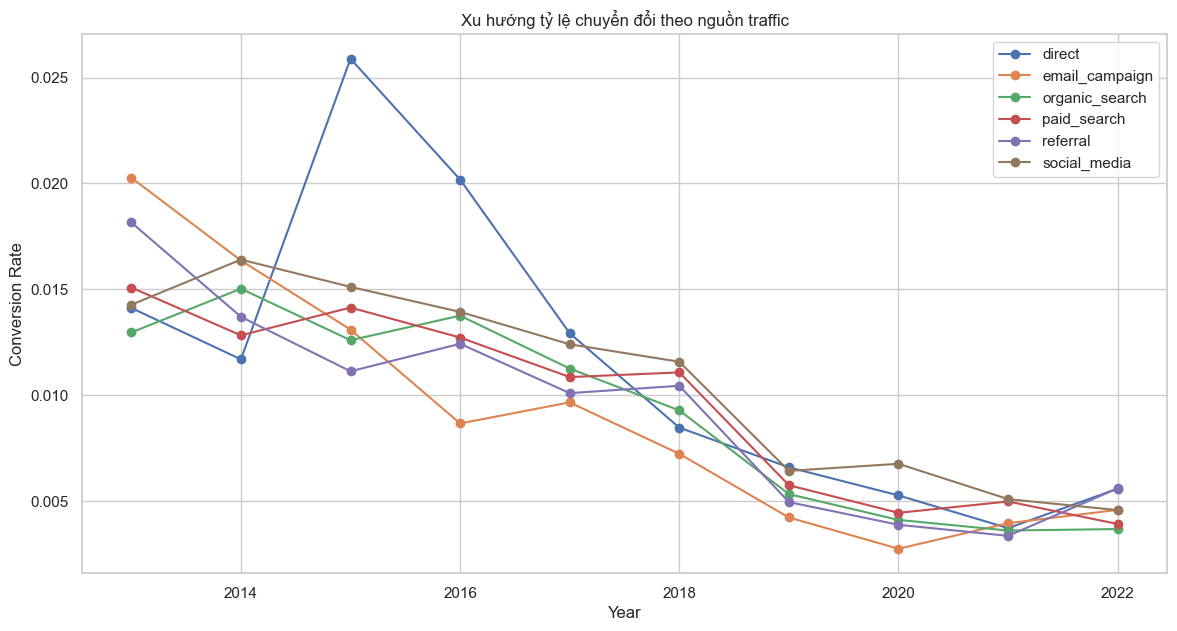

In [72]:
df_web_traffic['date'] = pd.to_datetime(df_web_traffic['date'])
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])
df_web_traffic['year'] = df_web_traffic['date'].dt.year
df_orders['year'] = df_orders['order_date'].dt.year
df_web_traffic['traffic_source'] = df_web_traffic['traffic_source'].str.lower().str.strip()
df_orders['order_source'] = df_orders['order_source'].str.lower().str.strip()


# =========================
# 2. AGGREGATE DATA
# =========================

# Traffic side
traffic_by_source = df_web_traffic.groupby(
    ['year', 'traffic_source']
)['unique_visitors'].sum().reset_index()

# Orders side
orders_by_source = df_orders.groupby(
    ['year', 'order_source']
)['order_id'].nunique().reset_index()


# =========================
# 3. MERGE DATA
# =========================

df_channel = traffic_by_source.merge(
    orders_by_source,
    left_on=['year', 'traffic_source'],
    right_on=['year', 'order_source'],
    how='left'
).fillna(0)

# Optional: drop duplicate column
df_channel.drop(columns=['order_source'], inplace=True)


# =========================
# 4. CONVERSION RATE
# =========================

df_channel['CR'] = df_channel['order_id'] / df_channel['unique_visitors']


# =========================
# 5. PIVOT FOR VISUALIZATION
# =========================

df_pivot = df_channel.pivot(
    index='traffic_source',
    columns='year',
    values='CR'
)


# =========================
# 6. PLOT (MULTI-LINE)
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for channel in df_pivot.index:
    plt.plot(
        df_pivot.columns,
        df_pivot.loc[channel],
        marker='o',
        label=channel
    )
plt.title("Xu hướng tỷ lệ chuyển đổi theo nguồn traffic")
plt.grid(True)
plt.xlabel("Year")
plt.ylabel("Conversion Rate")
plt.legend()
plt.grid(True)

plt.show()

Ta thấy rằng: All channels đều giảm có thể niềm tin thương hiệu (Brand Trust) đã bị xói mòn do tích tụ trải nghiệm tiêu cực (từ hàng lỗi) trong thời gian dài.Nếu vấn đề nằm ở marketing, CR sẽ giảm không đồng đều giữa các kênh. Tuy nhiên, dữ liệu cho thấy CR giảm trên tất cả các kênh.
	
>**Bác bỏ giả thuyết này**


2. Giả thuyết B: Suy giảm niềm tin khách hàng

In [73]:
# Tỷ lệ phần trăm các lý do trả hàng
# SQL: SELECT t1.*, t2.segment, t2.size FROM returns t1 JOIN products t2 ON t1.product_id = t2.product_id
# Pandas:
df_merged = df_returns.merge(
    df_products[['product_id', 'segment', 'size']], # Chỉ lấy những cột cần thiết từ bảng phải
    on='product_id', 
    how='left'
)
# Tổng số đơn trả hàng
total_returns = df_merged['return_id'].count()
# Đếm số lượng theo từng lý do
reason_counts = df_merged['return_reason'].value_counts()
# Tính tỷ lệ %
reason_percentage = (reason_counts / total_returns * 100)
print(reason_percentage)

return_reason
wrong_size          34.970831
defective           20.080623
not_as_described    17.614362
changed_mind        17.353965
late_delivery        9.980220
Name: count, dtype: float64


Hơn **50%** các đơn trả hàng không đến từ lỗi sản phẩm hay vận hành có thể đến từ việc khách hàng không có đủ thông tin chính xác để đưa ra quyết định đúng ngay từ đầu 


In [74]:
# Kiểm tra tỷ lệ lỗi 'wrong_size' trên toàn bộ các danh mục
# Tính tổng số đơn trả lại
total_returns = df_merged.groupby('segment')['return_id'].count()

# Tính số đơn trả lại do 'wrong_size'
wrong_size_returns = df_merged[df_merged['return_reason'] == 'wrong_size'].groupby('segment')['return_id'].count()

# Tỷ lệ phần trăm
percentage_wrong_size = (wrong_size_returns / total_returns * 100).fillna(0)

print("Tỷ lệ trả hàng do Wrong Size trên từng Segment:")
print(percentage_wrong_size)

Tỷ lệ trả hàng do Wrong Size trên từng Segment:
segment
Activewear     35.085976
All-weather    35.294118
Balanced       34.259754
Everyday       35.216405
Performance    35.391400
Premium        34.320557
Standard       34.109817
Trendy         34.477893
Name: return_id, dtype: float64


Tỷ lệ ~34–35% ở tất cả các segment
Không có sự khác biệt đáng kể giữa các nhóm sản phẩm


In [75]:
# Tỷ lệ lỗi `not_as_described` 

#  Merge cho bảng order_items (để lấy dữ liệu doanh thu/số lượng bán)
df_order_items_merged = df_order_items.merge(
    df_products[['product_id', 'segment', 'size']], 
    on='product_id', 
    how='left'
)
df_returns_merged = df_merged  # Bảng đã merge giữa returns và products để có segment và size

total_sales_by_seg = df_order_items_merged.groupby('segment')['quantity'].sum()
content_errors = df_returns_merged[df_returns_merged['return_reason'] == 'not_as_described'] \
                 .groupby('segment')['return_quantity'].sum()

content_failure_rate = (content_errors / total_sales_by_seg).fillna(0)
content_failure_rate

segment
Activewear     0.005990
All-weather    0.005438
Balanced       0.005917
Everyday       0.006000
Performance    0.006280
Premium        0.006245
Standard       0.005983
Trendy         0.006173
dtype: float64

Tỷ lệ lỗi `not_as_described` ổn định ở mức ~0.6% trên toàn bộ 8 phân khúc.


> Đây là một lỗi hệ thống, không phải lỗi cục bộ.

Câu hỏi đặt ra vậy vấn đề nằm ở đây mà khiến tất cả sản phẩm đều có tỷ lệ trả hàng xấp xỉ nhauu? Điều gì trong trải nghiệm mua hàng đang ảnh hưởng đồng loạt đến tất cả khách hàng, bất kể phân khúc sản phẩm?

Để kiểm chứng giả thuyết về sự suy giảm niềm tin khách hàng, nhóm tiến hành phân tích dữ liệu đánh giá (ratings) và nội dung phản hồi (review titles).


## III.3. Phân bố rating

In [76]:
df_reviews['sentiment'] = df_reviews['rating'].apply(
    lambda x: 'negative' if x <= 2 else ('neutral' if x == 3 else 'positive')
)

df_reviews['sentiment'].value_counts(normalize=True)

sentiment
positive    0.719219
neutral     0.149853
negative    0.130928
Name: proportion, dtype: float64

In [77]:
df_reviews['rating'].value_counts(normalize=True).sort_index()

rating
1    0.050832
2    0.080096
3    0.149853
4    0.320666
5    0.398552
Name: proportion, dtype: float64

Khoảng 72% đánh giá nằm ở mức 4–5 sao

Khoảng 28% còn lại từ 3 sao trở xuống

Ở mức tổng quan, hệ thống đánh giá dường như vẫn tích cực. Tuy nhiên, phân tích sâu hơn về nội dung phản hồi cho thấy một bức tranh khác biệt.


In [78]:
low_reviews = df_reviews[df_reviews['rating'] <= 2]

result = low_reviews['review_title'].value_counts().reset_index()
result.columns = ['review_title', 'count']

result

,review_title,count
0,Some issues,3037
1,Would not reorder,3034
2,Below expectations,3024
3,Would not recommend,1460
4,Poor quality,1443
5,Very disappointed,1442
6,Not as described,1427


> Phản hồi tiêu cực của khách hàng bị “tập trung hóa” vào một số nhóm cố định

1. Vấn đề chất lượng sản phẩm

    - Poor quality
    - Very disappointed

> nghĩa là hàng không đạt kỳ vọng về chất lượng

2. Sai lệch kỳ vọng (expectation mismatch)

    - Below expectations
    - Not as described

> khách thấy sản phẩm không giống mô tả / hình ảnh

3. Hối tiếc sau mua hàng

    - Would not reorder
    - Would not recommend
    - Some issues

> khách không muốn quay lại hoặc không hài lòng tổng thể

Mặc dù rating trung bình vẫn ở mức cao, nội dung phản hồi lại cho thấy sự bất mãn tiềm ẩn trong trải nghiệm khách hàng.

Có thể khách hàng không phản ứng mạnh bằng rating thấp nhưng lại âm thầm rời bỏ thương hiệu hay chăng?


## III.4. Tính AOV

AOV (Average Order Value) là chỉ số Giá trị đơn hàng trung bình, đo lường số tiền trung bình khách hàng chi tiêu cho mỗi lần mua hàng

In [79]:
yr = df_sales.groupby(df_sales["Date"].dt.year)["Revenue"].sum().reset_index()
yr.columns = ["year", "revenue"]
orders_year = df_orders.groupby(df_orders["order_date"].dt.year)["order_id"].nunique().reset_index()
orders_year.columns = ["year", "orders"]
yr = yr.merge(orders_year, on="year", how="left")
yr["aov"] = yr["revenue"] / yr["orders"]

Text(0.5, 1.0, 'Doanh thu và số đơn hàng theo năm')

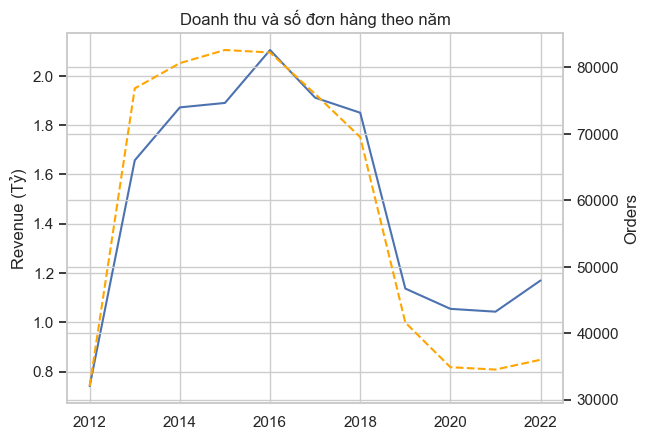

In [80]:
fig, ax1 = plt.subplots()

ax1.plot(yr["year"], yr["revenue"]/1e9, label="Revenue")
ax1.set_ylabel("Revenue (Tỷ)")

ax2 = ax1.twinx()
ax2.plot(yr["year"], yr["orders"], linestyle="--", label="Orders", color="orange")
ax2.set_ylabel("Orders")

plt.title("Doanh thu và số đơn hàng theo năm")

Text(0.5, 1.0, 'Doanh thu và AOV theo thời gian')

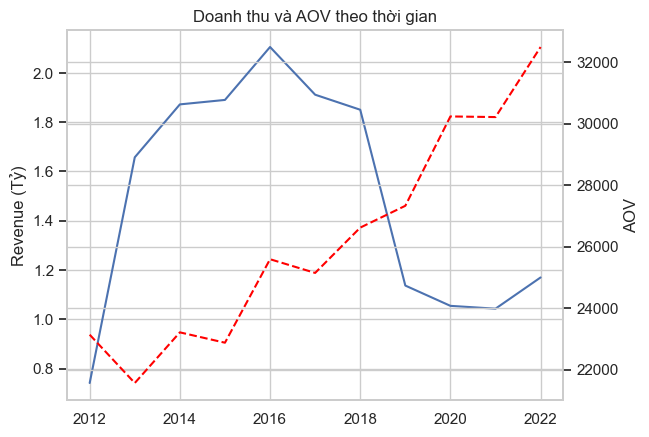

In [81]:
fig, ax1 = plt.subplots()

# Revenue
ax1.plot(yr["year"], yr["revenue"]/1e9)
ax1.set_ylabel("Revenue (Tỷ)")

# AOV (trục phụ)
ax2 = ax1.twinx()
ax2.plot(yr["year"], yr["aov"], linestyle="--",  color="red")
ax2.set_ylabel("AOV")

plt.title("Doanh thu và AOV theo thời gian")

Doanh thu có xu hướng giảm cùng với số lượng đơn hàng, đặc biệt sau năm 2016. Điều này cho thấy sự sụt giảm doanh thu chủ yếu đến từ việc giảm số lượng đơn hàng, thay vì do giá trị mỗi đơn (AOV). Mặc dù AOV có xu hướng tăng, nhưng không đủ bù đắp cho sự giảm mạnh về số lượng đơn.

## III.5. New vs Returning customers

In [82]:
df_orders["order_date"] = pd.to_datetime(df_orders["order_date"])
df_orders["year"] = df_orders["order_date"].dt.year
df_orders = df_orders.sort_values("order_date")
df_orders["first_purchase"] = df_orders.groupby("customer_id")["order_date"].transform("min")
df_orders["is_new"] = df_orders["order_date"] == df_orders["first_purchase"]

new_customers = (
    df_orders[df_orders["is_new"]]
    .groupby("year")["customer_id"]
    .nunique()
)

returning_customers = (
    df_orders[~df_orders["is_new"]]
    .groupby("year")["customer_id"]
    .nunique()
)

new_customers, returning_customers = new_customers.align(returning_customers, fill_value=0)

In [83]:
total_customers = df_orders.groupby("year")["customer_id"].nunique()

new_ratio = new_customers / total_customers
returning_ratio = returning_customers / total_customers

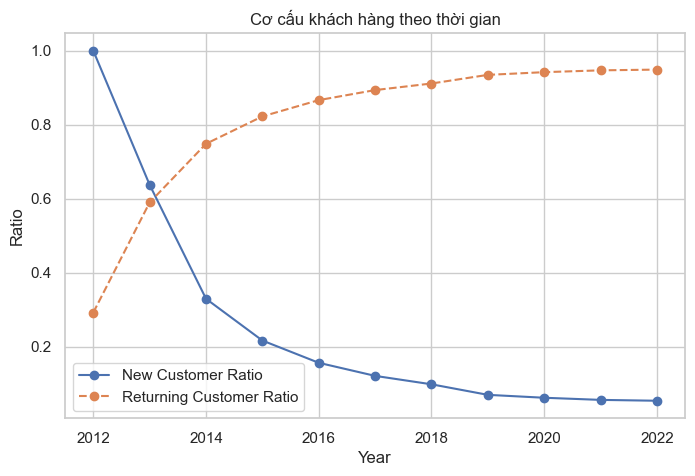

In [84]:
plt.figure(figsize=(8,5))

plt.plot(new_ratio.index, new_ratio.values, marker="o", label="New Customer Ratio")
plt.plot(returning_ratio.index, returning_ratio.values, marker="o", linestyle="--", label="Returning Customer Ratio")

plt.title("Cơ cấu khách hàng theo thời gian")
plt.xlabel("Year")
plt.ylabel("Ratio")

plt.legend()
plt.grid(True)

plt.show()

In [85]:
returning_ratio

year
2012    0.292097
2013    0.589833
2014    0.748440
2015    0.822481
2016    0.866465
2017    0.893647
2018    0.911423
2019    0.934791
2020    0.942100
2021    0.947006
2022    0.949020
Name: customer_id, dtype: float64

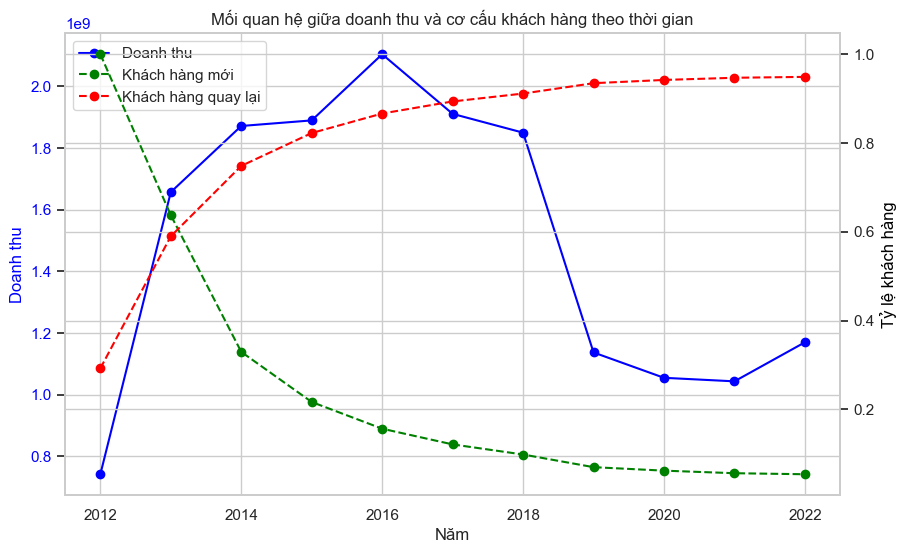

In [86]:

df_sales["Date"] = pd.to_datetime(df_sales["Date"])
df_sales["year"] = df_sales["Date"].dt.year
# Revenue theo năm
revenue_by_year = df_sales.groupby("year")["Revenue"].sum()

fig, ax1 = plt.subplots(figsize=(10,6))

# Revenue
ax1.plot(revenue_by_year.index, revenue_by_year.values,
         marker="o", color="blue", label="Doanh thu")
ax1.set_xlabel("Năm")
ax1.set_ylabel("Doanh thu", color="blue")
ax1.tick_params(axis='y', labelcolor="blue")

# Customer ratio (trục phụ)
ax2 = ax1.twinx()

ax2.plot(new_ratio.index, new_ratio.values,
         marker="o", linestyle="--", color="green", label="Khách hàng mới")

ax2.plot(returning_ratio.index, returning_ratio.values,
         marker="o", linestyle="--", color="red", label="Khách hàng quay lại")

ax2.set_ylabel("Tỷ lệ khách hàng", color="black")

plt.title("Mối quan hệ giữa doanh thu và cơ cấu khách hàng theo thời gian")

# gộp legend
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.show()

- Tỷ lệ khách hàng quay lại tăng mạnh trong giai đoạn đầu (2012–2015), sau đó tăng chậm và dần ổn định quanh mức ~94–95% từ năm 2019 trở đi. Điều này cho thấy doanh nghiệp đã đạt trạng thái bão hòa về khả năng giữ chân khách hàng. Tăng trưởng trong tương lai nhiều khả năng không còn đến từ cải thiện retention mà sẽ phụ thuộc vào mở rộng tệp khách hàng mới hoặc tăng giá trị trên mỗi khách hàng hiện tại.

- Tỷ lệ khách hàng quay lại tăng không phải do cải thiện sự trung thành, mà do sự sụt giảm mạnh của khách hàng mới. Điều này cho thấy hệ thống đang gặp vấn đề trong việc thu hút khách hàng mới, dẫn đến việc phụ thuộc vào một tập khách hàng hiện hữu ngày càng nhỏ.

- Mặc dù tỷ lệ khách hàng quay lại tăng theo thời gian, điều này không phản ánh sự cải thiện về mức độ trung thành. Ngược lại, tỷ lệ khách hàng mới giảm mạnh cho thấy nền tảng đang gặp khó khăn trong việc thu hút người dùng mới. Kết hợp với các phản hồi tiêu cực từ khách hàng, có thể thấy dấu hiệu suy giảm niềm tin, khiến khách hàng không quay lại và hạn chế việc lan tỏa tích cực. Điều này dẫn đến việc số lượng đơn hàng giảm, trong khi AOV tăng do chỉ còn lại nhóm khách hàng có mức chi tiêu cao hơn.